# **Proyecto Satisfacción del Turista de Sevilla**

##**Práctica en el Instituto de Estadística y Cartografía de Andalucía (IECA)**

### **Objetivos:**

1.   Medir la satisfacción general del turista mediante un análisis de sentimiento de los comentarios publicados en los sitios web de Civitatis y TripAdvisor.

2.	Determinar la satisfacción del turista según el tipo de viaje realizado: solo, en pareja, en familia, con amigos o de negocios.

3.	Comparar la satisfacción de los turistas residentes españoles versus los extranjeros.

4. Identificar los principales atractivos y locaciones turísticas mejor y menos valoradas.

5.	Analizar la percepción general del turista, por medio de visualizaciones de datos textuales, conteo de palabras más frecuentes, extracción y agrupación de comentarios por temas relacionados con aspectos claves de la calidad del servicio y experiencia turística.




In [ ]:
# Montar al Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

# Carga de los datos
df = pd.read_csv('/content/drive/MyDrive/datosturistas.csv') # Copiar la ruta del archivo en Google Drive
df.head()

,Destino,web_scraper_order,Fuente,URL,Fecha de Publicación,Nombre del Usuario,Título del Comentario,Fecha de Viaje,Tipo de Viaje,Comentario,Lugar de Procedencia,País,Residente/Extranjero,Comunidad o Ciudad Autónoma
0,Tour misterios y leyendas de Sevilla,1776039717-18,Civitatis,https://www.civitatis.com/es/sevilla/free-tour...,28/02/2025,Abel,No especificado,No especificado,Viajó con hijos pequeños,Todo genial. Nuestra guía Laura fue fantástica...,"Huelva, España",España,Residente,Andalucía
1,Barrio Santa Cruz,1776039231-6,Civitatis,https://www.civitatis.com/es/sevilla/free-tour...,28/01/2025,Adalía,No especificado,No especificado,Viajó en pareja,Un tour muy dinámico y bien explicado por un b...,"Las Palmas De Gran Canaria, España",España,Residente,Islas Canarias
2,Isla Mágica,1775652240-9,TripAdvisor,https://www.tripadvisor.es/Attraction_Review-g...,08/08/2025,Brian D,No especificado,Aug-25,No especificado,Experiencia pirata no sirve solo es publicidad...,"Las Palmas de Gran Canaria, España",España,Residente,Islas Canarias
3,Tour misterios y leyendas de Sevilla,1776039567-18,Civitatis,https://www.civitatis.com/es/sevilla/free-tour...,22/03/2026,Adelina,No especificado,No especificado,Viajó con amigos,"Aprendimos muchas curiosidades, fue una visita...","Albacete, España",España,Residente,Castilla-La Mancha
4,Free tour por Sevilla,1775828897-13,Civitatis,https://www.civitatis.com/es/sevilla/visita-gu...,21/02/2026,Adria,No especificado,No especificado,Viajó con amigos,"José es un tío excelente, muy recomendado. Par...","Os De Balaguer, España",España,Residente,Cataluña


In [ ]:
# Dimensiones del conjunto de datos
print(df.shape)

(3937, 14)


El conjunto de datos tiene 3937 filas (registros de comentarios) y 14 columnas (variables).

# **Transformación de los datos**

In [ ]:
# Información general de las columnas del data frame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3937 entries, 0 to 3936
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Destino                      3937 non-null   object
 1   web_scraper_order            3937 non-null   object
 2   Fuente                       3937 non-null   object
 3   URL                          3937 non-null   object
 4   Fecha de Publicación         3937 non-null   object
 5   Nombre del Usuario           3937 non-null   object
 6   Título del Comentario        3937 non-null   object
 7   Fecha de Viaje               3937 non-null   object
 8   Tipo de Viaje                3937 non-null   object
 9   Comentario                   3937 non-null   object
 10  Lugar de Procedencia         3937 non-null   object
 11  País                         3937 non-null   object
 12  Residente/Extranjero         3937 non-null   object
 13  Comunidad o Ciudad Autónoma  3937

In [ ]:
# Convertir a fecha la variable 'Fecha de Publicación'
df['Fecha de Publicación'] = pd.to_datetime(df['Fecha de Publicación'], format='%d/%m/%Y')

In [ ]:
# Convertir 'Fecha de Viaje' a datetime, excepto 'No especificado'
df['Fecha de Viaje'] = df['Fecha de Viaje'].apply(lambda x: pd.to_datetime(x, format='%d/%m/%Y', errors='coerce') if x != 'No especificado' else x)

In [ ]:
# Verificar si hay filas duplicadas
num_duplicate_rows = df.duplicated().sum()
print(f"Número de filas duplicadas: {num_duplicate_rows}")

Número de filas duplicadas: 0


# **Análisis exploratorio de los datos**

In [ ]:
# Valores únicos de 'Destino'
num_unique_destinos = df['Destino'].nunique()
print(f"La columna 'Destino' tiene {num_unique_destinos} valores únicos.")

La columna 'Destino' tiene 47 valores únicos.


In [ ]:
import pandas as pd

# Tabla de frecuencia absolutas y relativas de comentarios por 'Destino'
frecuencia_destino = df['Destino'].value_counts()
porcentaje_destino = df['Destino'].value_counts(normalize=True) * 100

tabla_destino = pd.DataFrame({
    'Frecuencia': frecuencia_destino,
    'Porcentaje': porcentaje_destino
})

display(tabla_destino.round(2))

,Frecuencia,Porcentaje
Destino,,
Free tour por Sevilla,445,11.30
Tour misterios y leyendas de Sevilla,438,11.13
Real Alcázar de Sevilla,363,9.22
Barrio Santa Cruz,310,7.87
Catedral de Sevilla,302,7.67
Setas de Sevilla,292,7.42
"Tour por la Catedral, el Alcázar y la Giralda",251,6.38
Archivo de Indias,233,5.92
Barrio Triana,208,5.28


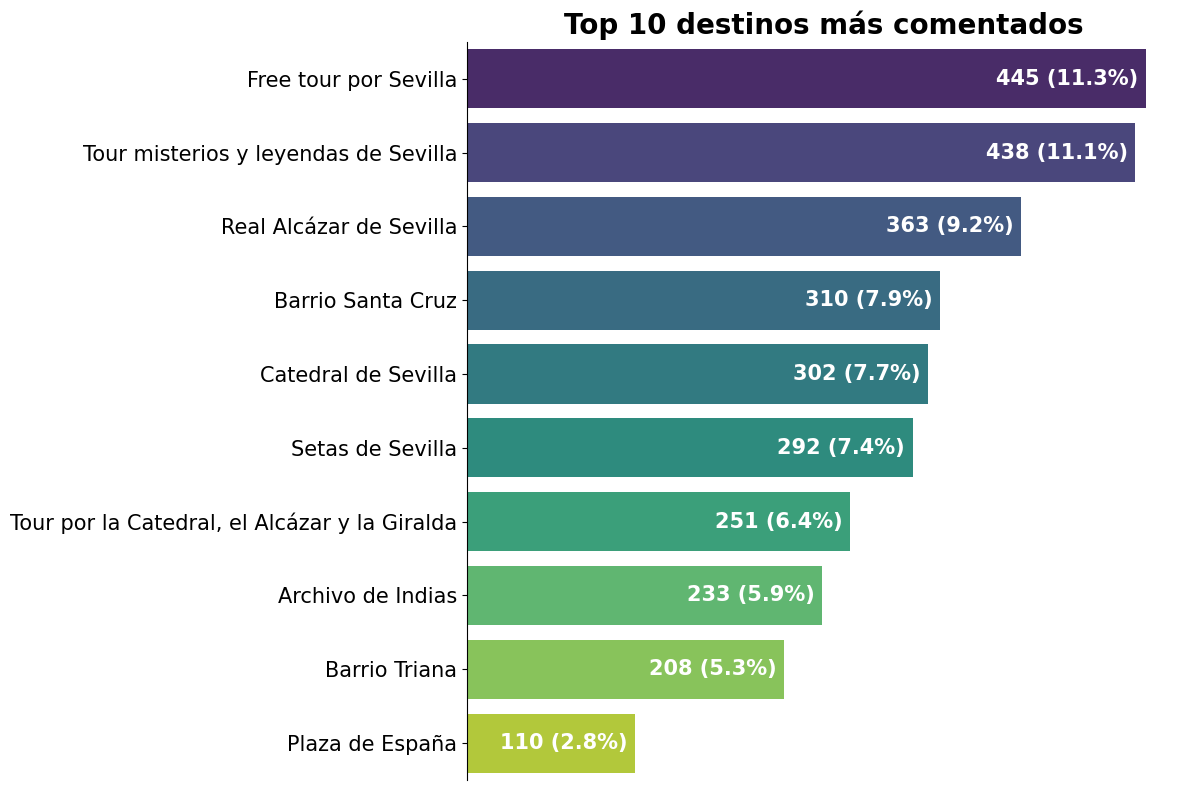

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Gráfico de barras de los 10 destinos más comentados

# Obtener los 10 destinos más comentados
top_10_destinos = tabla_destino.head(10)

# Crear el gráfico de barras horizontales
plt.figure(figsize=(12, 8))
sns.barplot(x='Frecuencia', y=top_10_destinos.index, data=top_10_destinos, palette='viridis', hue=top_10_destinos.index, legend=False)

# Añadir etiquetas de frecuencia y porcentaje a las barras
for i, row in top_10_destinos.iterrows():
    plt.text(row['Frecuencia'] - 5, i, f"{int(row['Frecuencia'])} ({row['Porcentaje']:.1f}%)",
             color='white', ha="right", va='center', fontsize=15, fontweight='bold')

plt.title('Top 10 destinos más comentados', fontsize=20, fontweight='bold', loc='center')
plt.xlabel('')
plt.ylabel('')
plt.xticks([]) # Eliminar las etiquetas del eje X
plt.tick_params(axis='x', length=0) # Eliminar los ticks del eje X
plt.yticks(fontsize=15)

# Quitar los bordes superior y derecho
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False) # Eliminar también la línea inferior del eje X

plt.tight_layout()
plt.show()

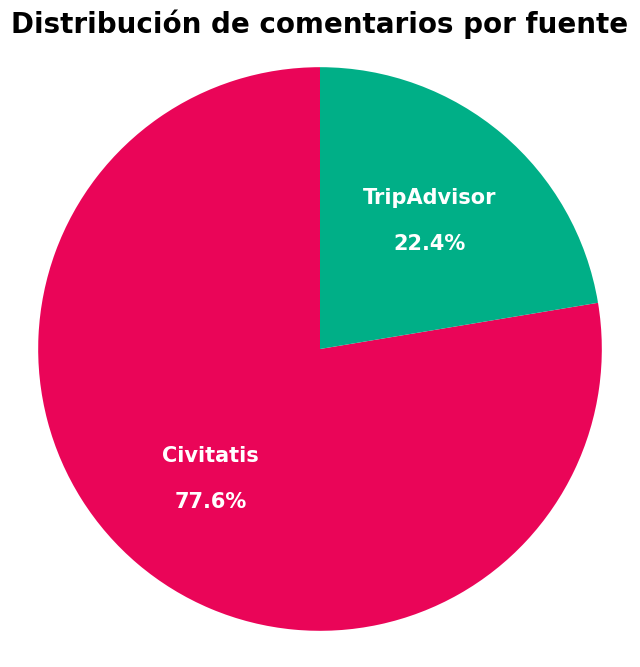

In [ ]:
import matplotlib.pyplot as plt

# Gráfico de tarta de comentarios por 'Fuente'

frecuencia_fuente = df['Fuente'].value_counts()

plt.figure(figsize=(8, 8))
# Definir los colores para Civitatis (rojo) y TripAdvisor (verde)
colors = ['#EA0558', '#00AF87'] # Civitatis (rojo), TripAdvisor (verde)

wedges, texts, autotexts = plt.pie(
    frecuencia_fuente,
    labels=None, # Eliminamos las etiquetas externas
    autopct='', # Remove default autopct, will create custom labels
    startangle=90,
    wedgeprops={'edgecolor': 'none'},
    colors=colors
)

# Establecer el color, tamaño, negrita y texto para las etiquetas de porcentaje para incluir la fuente y el porcentaje
for i, autotext in enumerate(autotexts):
    label = frecuencia_fuente.index[i]
    pct = frecuencia_fuente.values[i] / sum(frecuencia_fuente.values) * 100

    # Combinar la etiqueta de la fuente y el porcentaje con un espacio adicional
    autotext.set_text(f"{label}\n\n{pct:.1f}%") # Showing label and percentage with extra space
    autotext.set_color('white')
    autotext.set_fontsize(15)
    autotext.set_fontweight('bold')

# No se necesita el bucle para 'texts' ya que 'labels=None'

plt.title('Distribución de comentarios por fuente', fontsize=20, fontweight='bold') # Establecer el tamaño y negrita del título
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

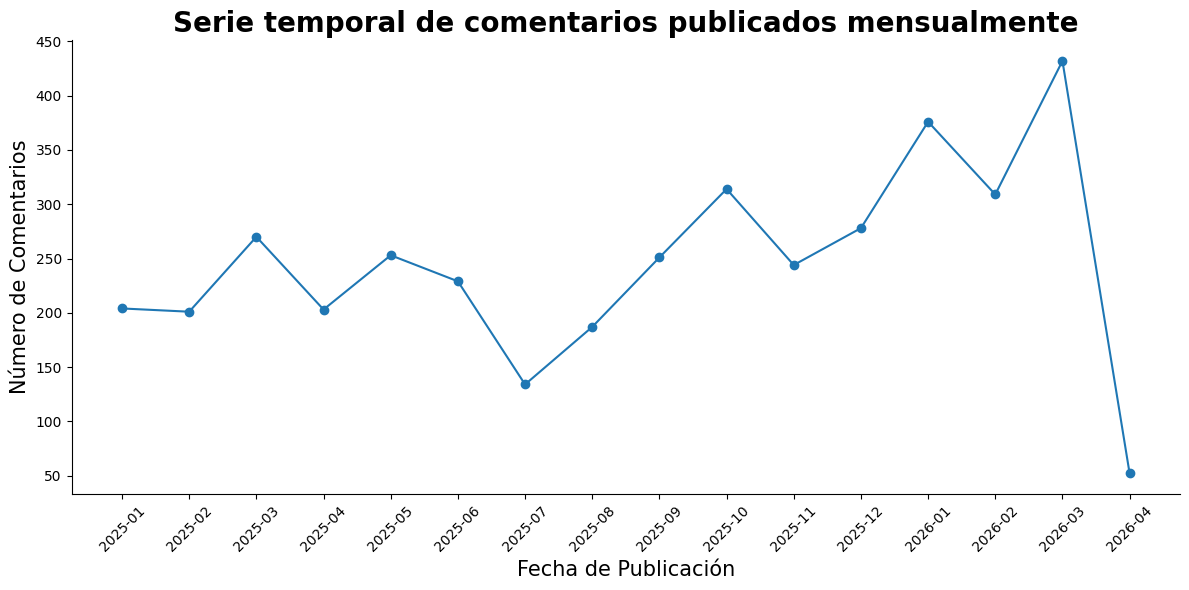

In [ ]:
import matplotlib.pyplot as plt

# Gráfico de línea de la serie mensual de comentarios publicados entre enero 2025 y abril 2026)

# Agrupar por mes y año de publicación y contar los comentarios
comentarios_por_mes = df['Fecha de Publicación'].dt.to_period('M').value_counts().sort_index()

# Convertir el índice a formato de cadena para la visualización
comentarios_por_mes.index = comentarios_por_mes.index.astype(str)

plt.figure(figsize=(12, 6))
plt.plot(comentarios_por_mes.index, comentarios_por_mes.values, marker='o', linestyle='-')
plt.title('Serie temporal de comentarios publicados mensualmente', fontsize=20, fontweight='bold')
plt.xlabel('Fecha de Publicación', fontsize=15)
plt.ylabel('Número de Comentarios', fontsize=15)
plt.xticks(rotation=45)

# Quitar los bordes superior y derecho
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
# Cálculo del promedio mensual de comentarios
promedio_mensual_comentarios = comentarios_por_mes.mean()
print(f"El promedio mensual de comentarios publicados es: {promedio_mensual_comentarios:.2f}")

El promedio mensual de comentarios publicados es: 246.06


Hubo un pico de mensajes en marzo de 2026, que coincide con la estacionalidad esperada en flujo de visitantes para Semana Santa.

In [ ]:
# Valores únicos de 'Nombre del Usuario'
num_unique_usuarios = df['Nombre del Usuario'].nunique()
print(f"La columna 'Nombre del Usuario' tiene {num_unique_usuarios} valores únicos.")

La columna 'Nombre del Usuario' tiene 2193 valores únicos.


Los comentarios analizados corresponden a 2192 usuarios diferentes, sin incluir los "Anónimos".

In [ ]:
# Usuarios que publicaron más de un comentario en la web

comentarios_por_usuario = df['Nombre del Usuario'].value_counts()
usuarios_repetidos = comentarios_por_usuario[comentarios_por_usuario > 1]

tabla_usuarios_repetidos = pd.DataFrame({
    'Número de Comentarios': usuarios_repetidos
})

# Agregar la columna de porcentaje
total_comentarios = len(df) # Asegurarse de que total_comentarios esté disponible
tabla_usuarios_repetidos['Porcentaje del Total'] = (tabla_usuarios_repetidos['Número de Comentarios'] / total_comentarios) * 100

display(tabla_usuarios_repetidos.round(2))

,Número de Comentarios,Porcentaje del Total
Nombre del Usuario,,
Anónimo,353,8.97
Laura,26,0.66
Ana,24,0.61
Carmen,23,0.58
Raquel,22,0.56
...,...,...
Agustín,2,0.05
Claudia,2,0.05
Miguel Gutierrez Berrocal,2,0.05


In [ ]:
# Sumar el total de comentarios observados
total_comentarios = len(df)

# Obtener comentarios anónimos
comentarios_anonimos = comentarios_por_usuario.get('Anónimo', 0)

# Calcular el total de comentarios anónimos
total_comentarios_sin_anonimos = total_comentarios - comentarios_anonimos

# Sumar el total de comentarios de usuarios que aparecen más de una vez
comentarios_de_usuarios_repetidos = usuarios_repetidos.sum()

print(f"Total de comentarios: {total_comentarios}")
print(f"Total de comentarios de usuarios Anónimo: {comentarios_anonimos}")
print(f"Total de comentarios sin incluir Anónimo: {total_comentarios_sin_anonimos}")
print(f"Total de comentarios de usuarios (incluyendo anónimos) que comentaron más de una vez: {comentarios_de_usuarios_repetidos}")

Total de comentarios: 3937
Total de comentarios de usuarios Anónimo: 353
Total de comentarios sin incluir Anónimo: 3584
Total de comentarios de usuarios (incluyendo anónimos) que comentaron más de una vez: 2212


In [ ]:
print(f"Número de usuarios que aparecen más de una vez: {len(usuarios_repetidos)}")

Número de usuarios que aparecen más de una vez: 468


Hay 468 usuarios (incluyendo los anónimos) de 2193 que opinaron más de una vez (21,3%).

Los comentarios de usuarios anónimos son 353 de un total de 3937 comentarios observados (9% ).

Los comentarios de usuarios que opinaron más de una vez (incluyendo los anónimos) suman 2212 de un total de 3937 observaciones (56,2%).

In [ ]:
# Verificar valores "No especificado" en 'Título del Comentario', 'Fecha de Viaje', 'Tipo de Viaje' y 'Lugar de Procedencia'

columns_to_check = ['Título del Comentario', 'Fecha de Viaje', 'Tipo de Viaje', 'Lugar de Procedencia', 'Comunidad o Ciudad Autónoma']

results = []
for col in columns_to_check:
    count = (df[col] == 'No especificado').sum()
    percentage = (count / len(df)) * 100
    results.append({'Columna': col, 'Frecuencia': count, 'Porcentaje': percentage})

no_especificado_df = pd.DataFrame(results)
display(no_especificado_df.round(2))

,Columna,Frecuencia,Porcentaje
0,Título del Comentario,3066,77.88
1,Fecha de Viaje,3077,78.16
2,Tipo de Viaje,488,12.40
3,Lugar de Procedencia,878,22.30
4,Comunidad o Ciudad Autónoma,503,12.78


En Civitatis no existe la opción de titular el comentario o poner la fecha en que se realizó el viaje, pero en TripAdvisor sí.

El 22,3% de los comentarios corresponden a usuarios que no especificaron su lugar de procedencia, y el 12,4% no indicó el tipo de viaje en su comentario.

In [ ]:
# Tabla de frecuencias de 'Tipo de Viaje'

frecuencia_tipo_viaje = df['Tipo de Viaje'].value_counts()
porcentaje_tipo_viaje = df['Tipo de Viaje'].value_counts(normalize=True) * 100

tabla_tipo_viaje = pd.DataFrame({
    'Frecuencia': frecuencia_tipo_viaje,
    'Porcentaje': porcentaje_tipo_viaje
})

display(tabla_tipo_viaje.round(2))

,Frecuencia,Porcentaje
Tipo de Viaje,,
Viajó en pareja,1720,43.69
Viajó con amigos,701,17.81
No especificado,488,12.40
Viajó con hijos mayores,480,12.19
Viajó solo,344,8.74
Viajó con hijos pequeños,203,5.16
Negocios,1,0.03


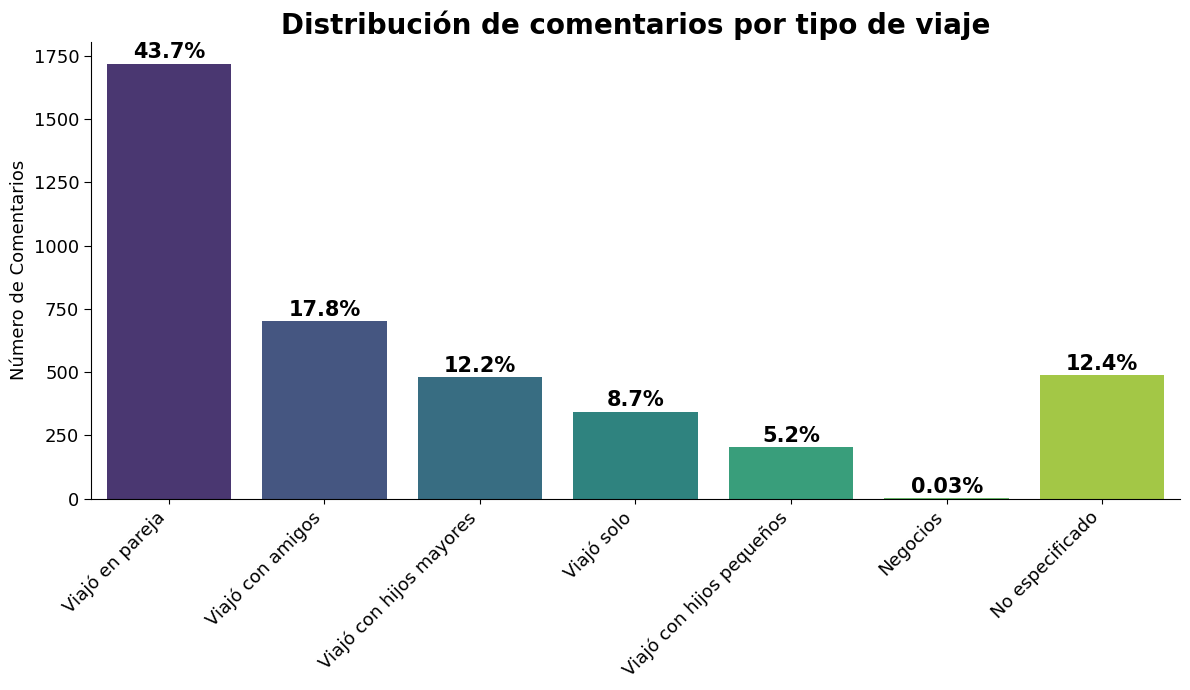

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Calcular la frecuencia y el porcentaje de cada tipo de viaje
frecuencia_tipo_viaje = df['Tipo de Viaje'].value_counts()
porcentaje_tipo_viaje = df['Tipo de Viaje'].value_counts(normalize=True) * 100

tabla_tipo_viaje = pd.DataFrame({
    'Frecuencia': frecuencia_tipo_viaje,
    'Porcentaje': porcentaje_tipo_viaje
})

# Separar 'No especificado'
no_especificado_row = tabla_tipo_viaje[tabla_tipo_viaje.index == 'No especificado']
otros_tipos_viaje = tabla_tipo_viaje[tabla_tipo_viaje.index != 'No especificado']

# Ordenar los otros tipos de viaje de mayor a menor frecuencia
otros_tipos_viaje_sorted = otros_tipos_viaje.sort_values(by='Frecuencia', ascending=False)

# Concatenar 'No especificado' al final
tabla_final_ordenada = pd.concat([otros_tipos_viaje_sorted, no_especificado_row])

# Crear el gráfico de barras verticales
plt.figure(figsize=(12, 7))
sns.barplot(x=tabla_final_ordenada.index, y='Frecuencia', data=tabla_final_ordenada, palette='viridis', hue=tabla_final_ordenada.index, legend=False)

# Añadir etiquetas de frecuencia y porcentaje encima de las barras
for i, row in enumerate(tabla_final_ordenada.itertuples()):
    # Formatear el porcentaje a un decimal, excepto para ' Negocios' para evitar que este se visualice como 0.0%
    if row.Index.strip() == 'Negocios':
        percentage_text = f"{row.Porcentaje:.2f}%"
    else:
        percentage_text = f"{row.Porcentaje:.1f}%"

    plt.text(i, row.Frecuencia + 5, percentage_text,
             color='black', ha="center", va='bottom', fontsize=15, fontweight='bold')

plt.title('Distribución de comentarios por tipo de viaje', fontsize=20, fontweight='bold')
plt.xlabel('')
plt.ylabel('Número de Comentarios', fontsize=13) # Mostrar etiqueta del eje Y
plt.xticks(rotation=45, ha='right', fontsize=13) # Rotar etiquetas del eje X para legibilidad
plt.yticks(fontsize=13) # Mostrar etiquetas del eje Y y establecer tamaño de fuente
plt.tick_params(axis='y', length=5) # Mostrar ticks del eje Y

# Quitar los bordes superior y derecho
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(True) # Asegurar que la línea izquierda del eje Y sea visible

plt.tight_layout()
plt.show()

La mayoría de los comentarios son de personas que viajaron en pareja, un 43,7%, considerando que el 12,4% de las opiniones contenidas en los datos no especificaron el tipo de viaje.

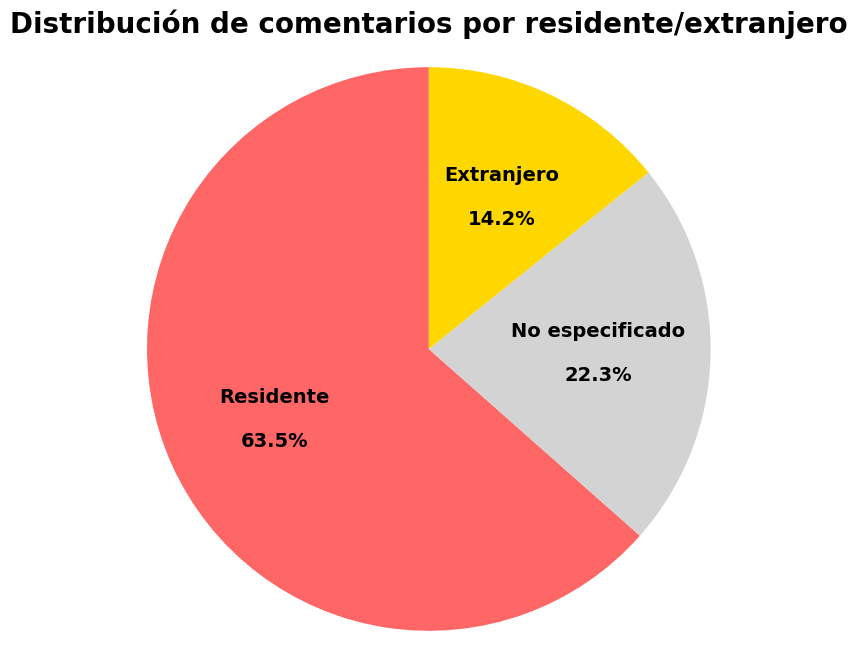

In [ ]:
import matplotlib.pyplot as plt

# Gráfico de tarta de comentarios de extranjeros y residentes

frecuencia_residente = df['Residente/Extranjero'].value_counts()

plt.figure(figsize=(8, 8))
# Colores definidos: Rojo para 'Residente', Gris claro'No especificado', Amarillo para 'Extranjero'

colors = ['#FF6666', '#D3D3D3', '#FFD700'] # Less saturated red, Light Gray, Less saturated yellow (e.g., Gold)

wedges, texts, autotexts = plt.pie(
    frecuencia_residente,
    labels=None, # Eliminamos las etiquetas externas
    autopct='',
    startangle=90,
    wedgeprops={'edgecolor': 'none'},
    colors=colors
)

# Establecer el color, tamaño, negrita y texto para las etiquetas de porcentaje para incluir la frecuencia y el nombre de la categoría
for i, autotext in enumerate(autotexts):
    label = frecuencia_residente.index[i]
    pct = frecuencia_residente.values[i] / sum(frecuencia_residente.values) * 100

    # Combinar la etiqueta y el porcentaje con un espacio adicional
    autotext.set_text(f"{label}\n\n{pct:.1f}%")
    autotext.set_fontsize(14) # Ajustar el tamaño de la fuente para que quepa
    autotext.set_fontweight('bold')

    # Establecer el color del texto según la etiqueta de la categoría
    if label == 'Residente':
        autotext.set_color('black') # Negro para 'Residente'
    else:
        autotext.set_color('black') # Negro para otras categorías

# No se necesita el bucle para 'texts' ya que 'labels=None'

plt.title('Distribución de comentarios por residente/extranjero', fontsize=20, fontweight='bold')
plt.axis('equal')
plt.show()

Ajustamos ahora el gráfico considerando los valores únicos de la variable 'Nombre del Usuario' distribuidos por su lugar de origen (residentes españoles o extranjeros).

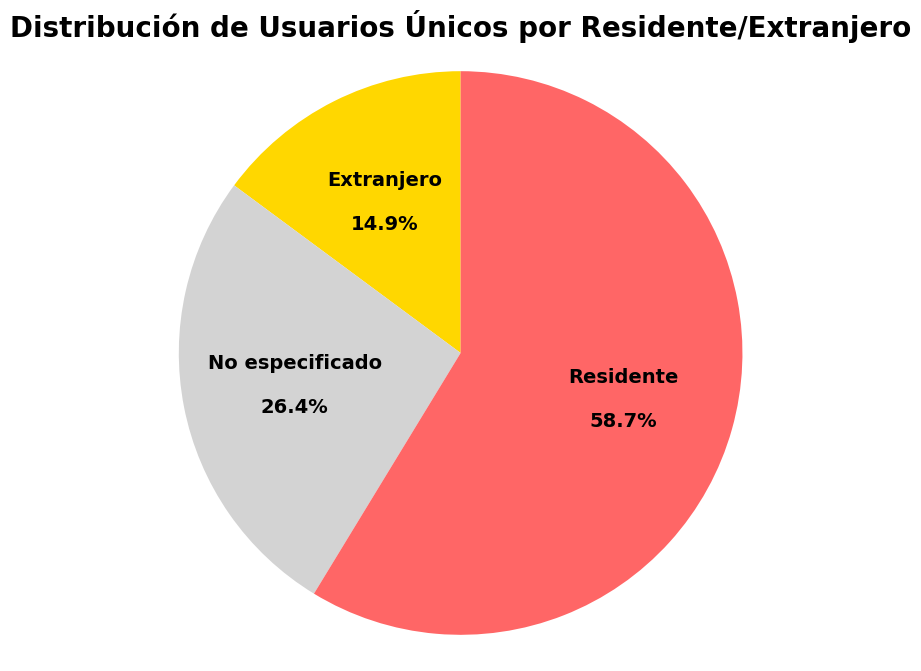

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Filtrar los comentarios para obtener usuarios únicos por 'Residente/Extranjero'
# Primero, asegurarse de que cada usuario se cuente solo una vez por su tipo de residencia
unique_users_by_residency = df.groupby('Residente/Extranjero')['Nombre del Usuario'].nunique()

# Preparar los datos para el gráfico de tarta
labels = unique_users_by_residency.index
sizes = unique_users_by_residency.values

# Definir los colores específicos para cada categoría
colors = {'Residente': '#FF6666', 'Extranjero': '#FFD700', 'No especificado': '#D3D3D3'}
# Asegurarse de que el orden de los colores coincida con el orden de las etiquetas
pie_colors = [colors[label] for label in labels]

plt.figure(figsize=(8, 8))
wedges, texts, autotexts = plt.pie(
    sizes,
    labels=None, # Eliminamos las etiquetas externas
    autopct='', # No usamos el autopct predeterminado
    startangle=90,
    wedgeprops={'edgecolor': 'none'},
    colors=pie_colors
)

# Establecer el color, tamaño, negrita y texto para las etiquetas de porcentaje para incluir la frecuencia y el nombre de la categoría
for i, autotext in enumerate(autotexts):
    label = labels[i]
    pct = sizes[i] / sum(sizes) * 100

    # Combinar la etiqueta y el porcentaje con un espacio adicional
    autotext.set_text(f"{label}\n\n{pct:.1f}%")
    autotext.set_fontsize(14) # Ajustar el tamaño de la fuente para que quepa
    autotext.set_fontweight('bold')
    autotext.set_color('black') # Color de texto uniforme para todas las etiquetas

plt.title('Distribución de Usuarios Únicos por Residente/Extranjero', fontsize=20, fontweight='bold')
plt.axis('equal')
plt.show()

In [ ]:
paises_filtrados = df[~df['País'].isin(['No especificado'])]
num_paises_unicos = paises_filtrados['País'].nunique()
print(f"Número de países únicos (excluyendo 'No especificado'): {num_paises_unicos}")

Número de países únicos (excluyendo 'No especificado'): 41


Hay 41 países diferentes (incluyendo España) reportados como lugar de procedencia de los usuarios.

In [ ]:
# Tabla de frecuencias de 'País'

frecuencia_pais = df['País'].value_counts()
porcentaje_pais = df['País'].value_counts(normalize=True) * 100

tabla_tipo_viaje = pd.DataFrame({
    'Frecuencia': frecuencia_pais,
    'Porcentaje': porcentaje_pais
})

display(tabla_tipo_viaje.round(2))

,Frecuencia,Porcentaje
País,,
España,2499,63.47
No especificado,873,22.17
Reino Unido,183,4.65
Italia,103,2.62
Francia,69,1.75
Estados Unidos,62,1.57
Argentina,24,0.61
Brasil,12,0.30
Irlanda,12,0.30


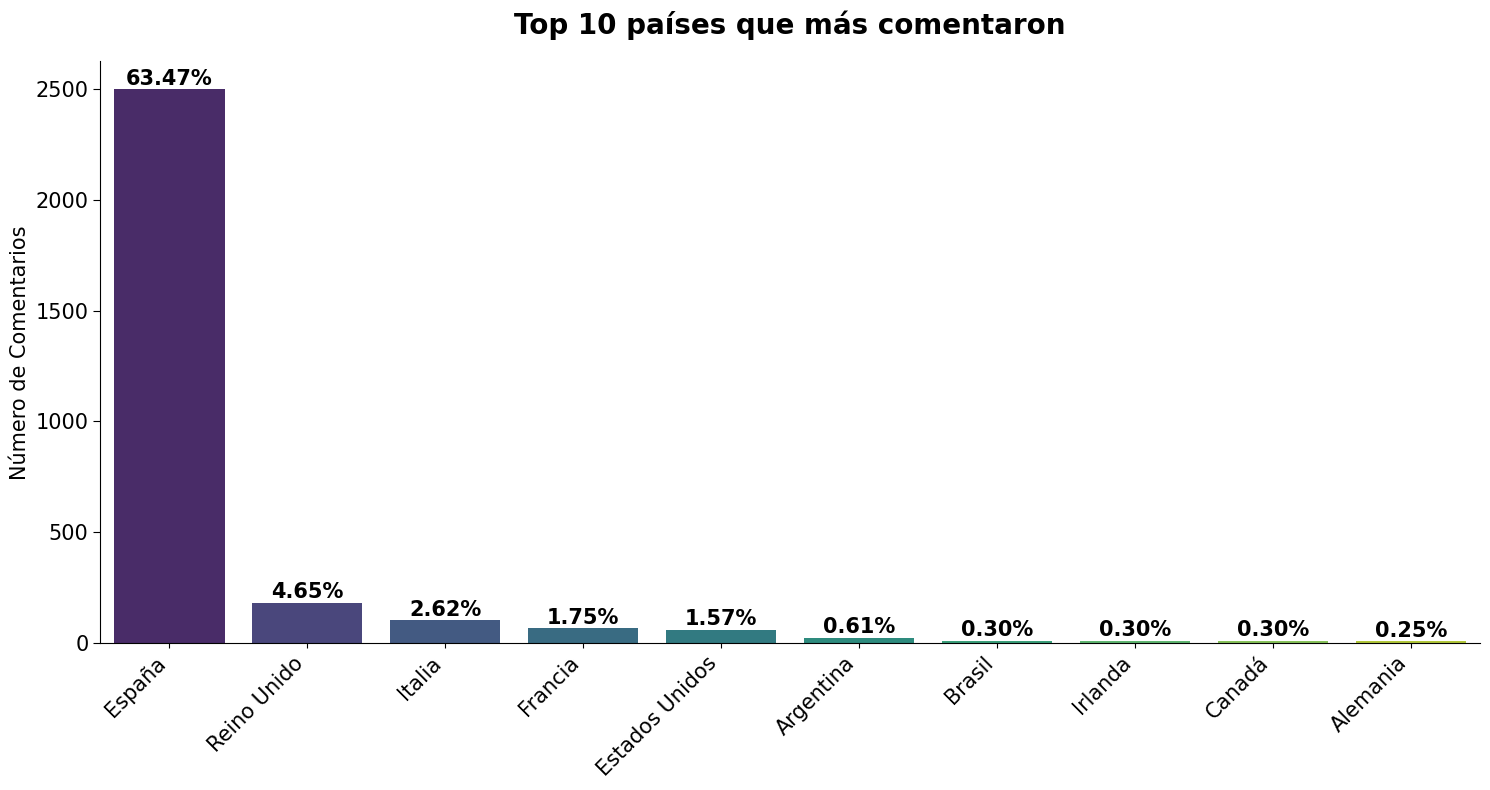

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

#Gráfico de barras Top 10 países que más comentaron

# Filtrar los países, excluyendo 'No especificado'
paises_filtrados = df[df['País'] != 'No especificado']

# Calcular la frecuencia absoluta de comentarios por 'País' en los datos filtrados
frecuencia_pais = paises_filtrados['País'].value_counts()
# Calcular la frecuencia relativa de comentarios por 'País' en base al total de comentarios (1542)
porcentaje_pais = (frecuencia_pais / len(df)) * 100

tabla_pais = pd.DataFrame({
    'Frecuencia': frecuencia_pais,
    'Porcentaje': porcentaje_pais
})

# Obtener los 10 países más comentados
top_10_paises = tabla_pais.head(10)

# Crear el gráfico de barras verticales
plt.figure(figsize=(15, 8)) # Aumentar el ancho para mejor visualización
sns.barplot(x=top_10_paises.index, y='Frecuencia', data=top_10_paises, palette='viridis', hue=top_10_paises.index, legend=False)

# Añadir etiquetas de frecuencia y porcentaje encima de las barras
for i, row in top_10_paises.iterrows():
    plt.text(i, row['Frecuencia'] + 2, f"{row['Porcentaje']:.2f}%",
             color='black', ha="center", va='bottom', fontsize=15, fontweight='bold')

plt.title('Top 10 países que más comentaron', fontsize=20, fontweight='bold', loc='center', pad=20)
plt.xlabel('') # Eliminar etiqueta del eje X
plt.ylabel('Número de Comentarios', fontsize=15) # Agregar etiqueta del eje Y
plt.xticks(rotation=45, ha='right', fontsize=15) # Rotar etiquetas del eje X para legibilidad
plt.yticks(fontsize=15) # Mostrar las etiquetas del eje Y y establecer tamaño de fuente
plt.tick_params(axis='y', length=5) # Mostrar los ticks del eje Y

# Quitar los bordes superior y derecho
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(True) # Asegurar que la línea izquierda del eje Y sea visible

plt.tight_layout()
plt.show()

La mayoría de los comentarios observados son de españoles, un 63,5%, aclarando que hay  un 22,3% de  comentarios que no especificaron el lugar de procedencia. El 14,2% de los comentarios pertenecen a extranjeros, en estos, los británicos fueron los que más opinaron sobre su visita (4,7%).

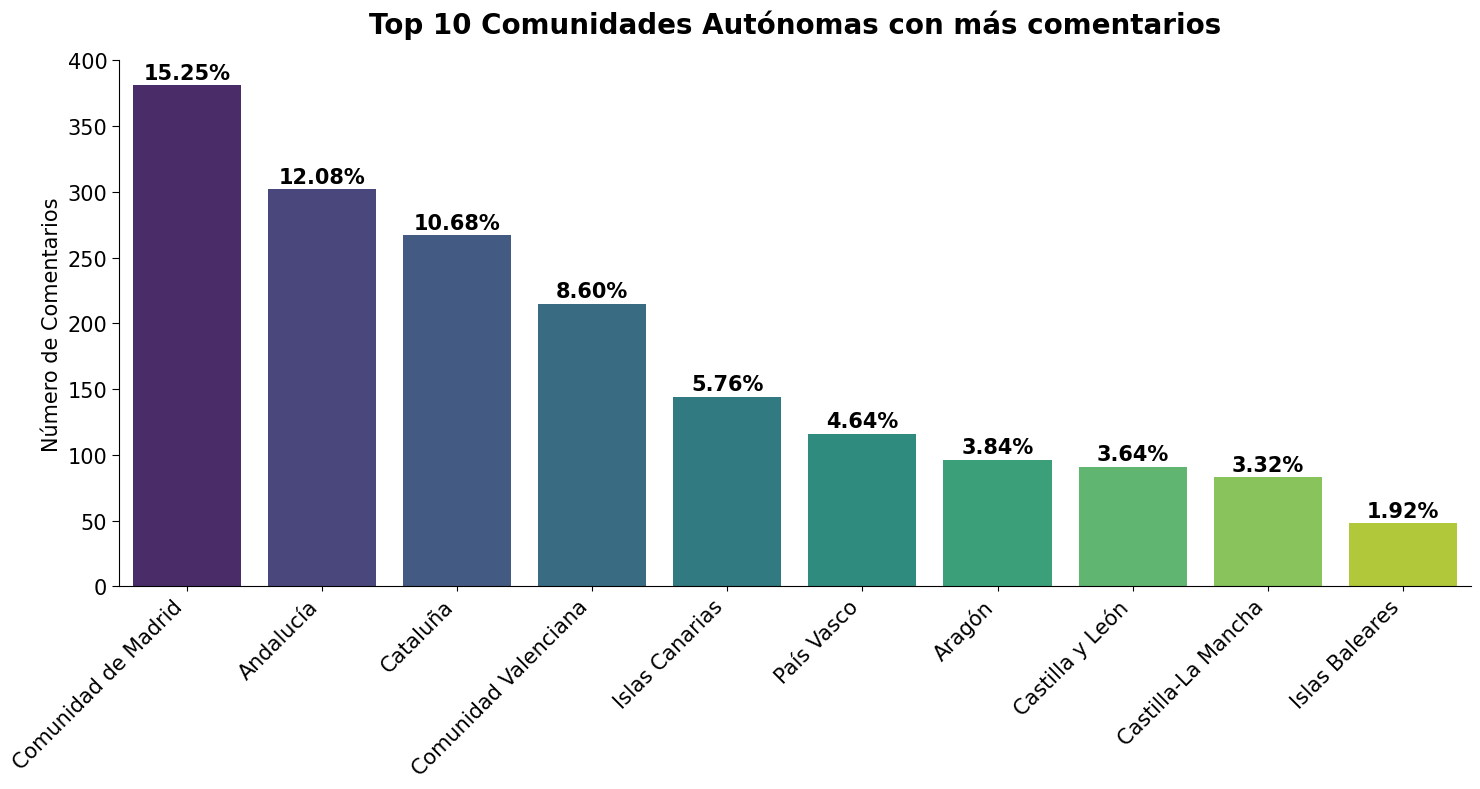

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filtrar el DataFrame para obtener solo los comentarios de residentes y excluir 'No Aplica' de 'Comunidad o Ciudad Autónoma'
# Usamos df_espanoles que ya está filtrado por País == 'España' para consistencia con la tabla.
df_espanoles_filtered_for_plot = df[(df['País'] == 'España') & (~df['Comunidad o Ciudad Autónoma'].isin(['No Aplica', 'No especificado']))].copy()

# Calcular la frecuencia absoluta de comentarios por 'Comunidad o Ciudad Autónoma' entre los residentes españoles filtrados
frecuencia_comunidad_residentes = df_espanoles_filtered_for_plot['Comunidad o Ciudad Autónoma'].value_counts()

# El total de residentes españoles se toma como len(df[df['País'] == 'España']) para consistencia
total_todos_comentarios_espanoles = len(df[df['País'] == 'España'])
porcentaje_comunidad_residentes = (frecuencia_comunidad_residentes / total_todos_comentarios_espanoles) * 100

tabla_comunidad_residentes = pd.DataFrame({
    'Frecuencia': frecuencia_comunidad_residentes,
    'Porcentaje': porcentaje_comunidad_residentes
})

# Obtener las 10 comunidades autónomas con más comentarios de residentes
top_10_comunidades_residentes = tabla_comunidad_residentes.head(10)

# Crear el gráfico de barras verticales
plt.figure(figsize=(15, 8))
sns.barplot(x=top_10_comunidades_residentes.index, y='Frecuencia', data=top_10_comunidades_residentes, palette='viridis', hue=top_10_comunidades_residentes.index, legend=False)

# Añadir etiquetas de frecuencia y porcentaje encima de las barras
for i, row in top_10_comunidades_residentes.iterrows():
    plt.text(i, row['Frecuencia'] + 2, f"{row['Porcentaje']:.2f}%",
             color='black', ha="center", va='bottom', fontsize=15, fontweight='bold')

plt.title('Top 10 Comunidades Autónomas con más comentarios', fontsize=20, fontweight='bold', loc='center', pad=20) # Added pad=20
plt.xlabel('')
plt.ylabel('Número de Comentarios', fontsize=15)
plt.xticks(rotation=45, ha='right', fontsize=15)
plt.yticks(fontsize=15)
plt.tick_params(axis='y', length=5)

# Quitar los bordes superior, derecho e izquierdo
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(True)

plt.tight_layout()
plt.show()

El gráfico abarca 1994 comentarios de españoles que sí reportaron su ciudad de procedencia. Hay 503 que no lo hicieron, por lo que es imposible saber a cuál comunidad pertenecen y están excluidos de este gráfico.

Los residentes de la Comunidad de Madrid (15,3%) fueron los que más comentaron sobre su visita a Sevilla, seguido de Andalucía (12,1%) y Cataluña (10,7%).

In [ ]:
import pandas as pd

# Filtrar los comentarios de residentes españoles
df_espanoles = df[df['País'] == 'España'].copy()

# Filtrar por comunidad autónoma, excluyendo 'No aplica' y 'No especificado'
df_espanoles_comunidad = df_espanoles[~df_espanoles['Comunidad o Ciudad Autónoma'].isin(['No Aplica', 'No especificado'])].copy()

# Calcular la frecuencia absoluta de comentarios por Comunidad Autónoma
frecuencia_comunidad = df_espanoles_comunidad['Comunidad o Ciudad Autónoma'].value_counts()

# Calcular el porcentaje en base al total de *todos* los comentarios de españoles (incluyendo los 'No aplica' y 'No especificado')
total_todos_comentarios_espanoles = len(df_espanoles) # Nuevo total para el porcentaje
porcentaje_comunidad = (frecuencia_comunidad / total_todos_comentarios_espanoles) * 100

# Crear la tabla de resultados
tabla_comentarios_espanoles_por_comunidad = pd.DataFrame({
    'Frecuencia': frecuencia_comunidad,
    'Porcentaje': porcentaje_comunidad
})

# Ordenar por frecuencia de forma descendente
tabla_comentarios_espanoles_por_comunidad = tabla_comentarios_espanoles_por_comunidad.sort_values(by='Frecuencia', ascending=False)

display(tabla_comentarios_espanoles_por_comunidad.round(2))

,Frecuencia,Porcentaje
Comunidad o Ciudad Autónoma,,
Comunidad de Madrid,381,15.25
Andalucía,302,12.08
Cataluña,267,10.68
Comunidad Valenciana,215,8.60
Islas Canarias,144,5.76
País Vasco,116,4.64
Aragón,96,3.84
Castilla y León,91,3.64
Castilla-La Mancha,83,3.32


# **Análisis de sentimientos con robertuito**

El modelo robertuito-sentiment-analysis está optimizado para el análisis de sentimiento en español y se basa en la arquitectura BERT.

### **Paso 1: Instalar las bibliotecas necesarias**

Necesitamos 'transformers' para interactuar con los modelos pre-entrenados y 'pysentimiento' que contiene el modelo específico para análisis de sentimiento en español.

In [ ]:
!pip install transformers pysentimiento

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 13.7 MB/s eta 0:00:00


### **Paso 2: Cargar el modelo de análisis de sentimiento**

Utilizaremos el modelo pre-entrenado `robertuito-sentiment-analysis`, que está optimizado para el español y clasifica los textos en `POS` (positivo), `NEG` (negativo) o `NEU` (neutro).

In [ ]:
from pysentimiento import create_analyzer

# Cargar el analizador de sentimiento para español
analyzer = create_analyzer(task="sentiment", lang="es")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/925 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/435M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.31M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

### **Paso 3: Preparación de los datos textuales**

Antes de pasar los comentarios al modelo, es recomendable realizar algunas tareas de preprocesamiento para limpiar el texto. Esto incluye eliminar URLs, menciones de usuario, hashtags, emojis y caracteres especiales. Además, convertiremos el texto a minúsculas para estandarizarlo.

Crearemos una función para aplicar estas transformaciones a la columna 'Comentario'.

In [ ]:
import re
import emoji

def preprocess_text(text):
    # Convertir a cadena si no lo es (manejar posibles números, etc.)
    text = str(text)
    # Eliminar URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # Eliminar menciones de usuario (@username)
    text = re.sub(r'@\w+', '', text)
    # Eliminar hashtags (#hashtag)
    text = re.sub(r'#\w+', '', text)
    # Eliminar emojis
    text = emoji.demojize(text)
    text = re.sub(r':\S+:', '', text) # Eliminar textos de emoji como :smile:
    # Eliminar caracteres no alfanuméricos y múltiples espacios
    text = re.sub(r'[^\w\s]', '', text) # Elimina puntuación y caracteres especiales
    text = re.sub(r'\s+', ' ', text).strip() # Reemplaza múltiples espacios por uno solo y elimina espacios al inicio/final
    # Convertir a minúsculas
    text = text.lower()
    return text

# Aplicar la función de preprocesamiento a la columna 'Comentario'
df['Comentario_limpio'] = df['Comentario'].apply(preprocess_text)

### **Paso 4: Realizar el análisis de sentimiento**

Ahora aplicaremos el modelo `analyzer` a la columna `Comentario_limpio`. El resultado de cada comentario será una predicción de sentimiento (positivo, negativo o neutro) y una puntuación de probabilidad asociada a esa predicción. Crearemos nuevas columnas en el DataFrame para almacenar estos resultados.

In [ ]:
# Función para obtener el sentimiento y la puntuación de un comentario
def get_sentiment_and_score(text):
    if pd.isna(text) or text == '': # Manejar valores nulos o vacíos
        return None, None
    output = analyzer.predict(text)
    sentiment = output.output
    # La puntuación es la probabilidad asociada al sentimiento predicho
    score = output.probas[sentiment]
    return sentiment, score

# Aplicar el análisis de sentimiento a la columna 'Comentario_limpio'
df[['Sentimiento', 'Puntuacion_Sentimiento']] = df['Comentario_limpio'].apply(lambda x: pd.Series(get_sentiment_and_score(x)))

# Mostrar las primeras filas con los nuevos resultados
print(df[['Comentario', 'Comentario_limpio', 'Sentimiento', 'Puntuacion_Sentimiento']].head())

                                          Comentario  \
0  Todo genial. Nuestra guía Laura fue fantástica...   
1  Un tour muy dinámico y bien explicado por un b...   
2  Experiencia pirata no sirve solo es publicidad...   
3  Aprendimos muchas curiosidades, fue una visita...   
4  José es un tío excelente, muy recomendado. Par...   

                                   Comentario_limpio Sentimiento  \
0  todo genial nuestra guía laura fue fantástica ...         POS   
1  un tour muy dinámico y bien explicado por un b...         POS   
2  experiencia pirata no sirve solo es publicidad...         NEG   
3  aprendimos muchas curiosidades fue una visita ...         POS   
4  josé es un tío excelente muy recomendado para ...         POS   

   Puntuacion_Sentimiento  
0                0.979932  
1                0.979342  
2                0.954234  
3                0.975593  
4                0.976173  


In [ ]:
import pandas as pd

# 1. Definir una función para obtener todas las probabilidades de sentimiento
# Esto requiere volver a ejecutar la predicción para cada comentario, ya que el diccionario completo de 'probas' no se almacenó previamente.
def get_sentiment_probas(text):
    if pd.isna(text) or text == '':
        return {'POS': None, 'NEG': None, 'NEU': None}
    output = analyzer.predict(text)
    return output.probas

# 2. Aplicar la función a la columna 'Comentario_limpio'
# Esto creará una Serie donde cada elemento es un diccionario de probabilidades
probas_series = df['Comentario_limpio'].apply(get_sentiment_probas)

# 3. Expandir los diccionarios en nuevas columnas y concatenarlas al DataFrame original
probas_df = probas_series.apply(pd.Series)

# Renombrar las columnas como se solicitó
probas_df = probas_df.rename(columns={
    'POS': 'Probabilidad Sentimiento POS',
    'NEG': 'Probabilidad Sentimiento NEG',
    'NEU': 'Probabilidad Sentimiento NEU'
})

# Concatenar estas nuevas columnas al DataFrame original
df = pd.concat([df, probas_df], axis=1)

# Mostrar las primeras filas con los nuevos resultados
print(df[['Comentario', 'Comentario_limpio', 'Sentimiento', 'Puntuacion_Sentimiento', 'Probabilidad Sentimiento POS', 'Probabilidad Sentimiento NEG', 'Probabilidad Sentimiento NEU']].head())

                                          Comentario  \
0  Todo genial. Nuestra guía Laura fue fantástica...   
1  Un tour muy dinámico y bien explicado por un b...   
2  Experiencia pirata no sirve solo es publicidad...   
3  Aprendimos muchas curiosidades, fue una visita...   
4  José es un tío excelente, muy recomendado. Par...   

                                   Comentario_limpio Sentimiento  \
0  todo genial nuestra guía laura fue fantástica ...         POS   
1  un tour muy dinámico y bien explicado por un b...         POS   
2  experiencia pirata no sirve solo es publicidad...         NEG   
3  aprendimos muchas curiosidades fue una visita ...         POS   
4  josé es un tío excelente muy recomendado para ...         POS   

   Puntuacion_Sentimiento  Probabilidad Sentimiento POS  \
0                0.979932                      0.979932   
1                0.979342                      0.979342   
2                0.954234                      0.005486   
3                0

In [ ]:
# Antes de guardar, limpiar caracteres ilegales para Excel en todas las columnas de texto
import re

def clean_excel_illegal_chars(text):
    if isinstance(text, str):
        # Eliminar o reemplazar caracteres que openpyxl considera ilegales
        # Incluye: newline (\n), carriage return (\r), vertical tab (\v), form feed (\f), null (\x00)
        # Se reemplazan por un espacio para mantener cierta legibilidad, aunque eliminar también es una opción.
        text = re.sub(r'[\n\r\v\f\x00]', ' ', text)
        # También se puede considerar eliminar otros caracteres de control si el problema persiste
        # text = re.sub(r'[\x00-\x08\x0b\x0c\x0e-\x1f]', '', text)
    return text

# Aplicar la limpieza a todas las columnas de tipo 'object' (que suelen ser strings)
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].apply(clean_excel_illegal_chars)

df.to_excel('/content/drive/MyDrive/sentimiento_comentarios.xlsx', index=False)
print("DataFrame 'df' con resultados de sentimiento guardado exitosamente en 'sentimiento_comentarios.xlsx' en Google Drive.")

DataFrame 'df' con resultados de sentimiento guardado exitosamente en 'sentimiento_comentarios.xlsx' en Google Drive.


In [ ]:
# Calcular la media de 'Puntuacion_Sentimiento' para cada categoría de 'Sentimiento_predicho'
mean_sentiment_score = df.groupby('Sentimiento')['Puntuacion_Sentimiento'].mean()

print("Media de Puntuación de Sentimiento por Categoría:")
print(mean_sentiment_score)

Media de Puntuación de Sentimiento por Categoría:
Sentimiento
NEG    0.844849
NEU    0.588824
POS    0.937345
Name: Puntuacion_Sentimiento, dtype: float64


In [ ]:
# Resumen estadístico de 'Puntuación_Sentimiento'
print(df['Puntuacion_Sentimiento'].describe())

count    3937.000000
mean        0.902394
std         0.139959
min         0.362089
25%         0.912012
50%         0.969425
75%         0.978129
max         0.987473
Name: Puntuacion_Sentimiento, dtype: float64


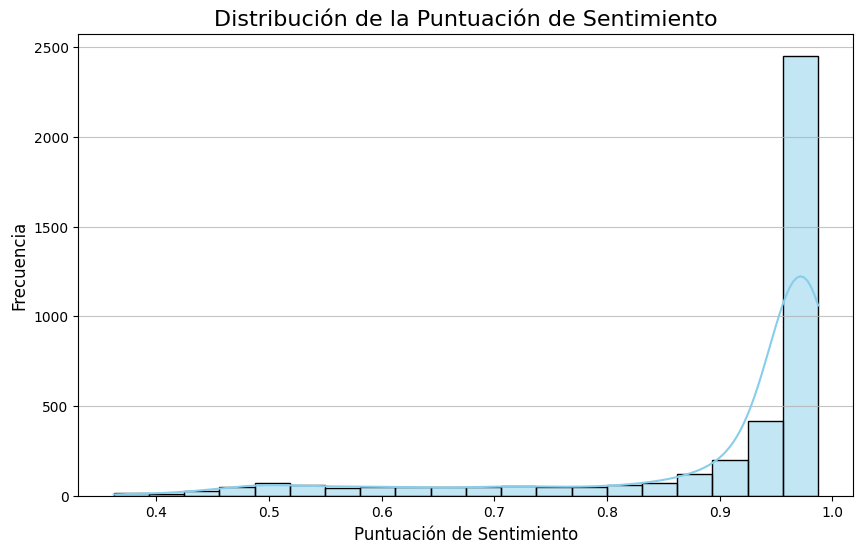

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['Puntuacion_Sentimiento'], bins=20, kde=True, color='skyblue')
plt.title('Distribución de la Puntuación de Sentimiento', fontsize=16)
plt.xlabel('Puntuación de Sentimiento', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.grid(axis='y', alpha=0.75)
plt.show()

Se analizaron 3937 comentarios. El modelo robertuito calcula una probabilidad para cada clase de sentimiento: positivo, negativo y neutro. La clase con la probabilidad más alta es la puntuación seleccionada para clasificar el comentario como positivo, negativo o neutro.

* **Media** (mean): La puntuación media de sentimiento es de
aproximadamente 0,90. Esto indica que, en promedio, la probabilidad calculada por el modelo para cada comentario fue de un 90% lo cual podría tomarse como el nivel de confianza del mismo.

* **Desviación Estándar** (std): La desviación estándar es de 0,14. Este valor relativamente bajo sugiere que las puntuaciones de sentimiento no están muy dispersas alrededor de la media.

* **Mínimo** (min): La puntuación más baja encontrada es 0,36.

* **Cuartiles**: El 25% de los comentarios tienen una puntuación de sentimiento igual o inferior a 0,91. La **mediana** (50%) es de 0,97, lo que significa que la mitad de los comentarios tienen una puntuación de sentimiento igual o inferior a este valor. El 75% de los comentarios tienen una puntuación de sentimiento igual o inferior a 0,98.

* **Máximo** (max): La puntuación más alta es 0,99. Con la mayoría de las puntuaciones concentradas en el rango superior. La media alta y la mediana cercana al máximo refuerzan la confiabilidad del modelo y es bastante bueno para clasificar con claridad el sentimiento de los textos.

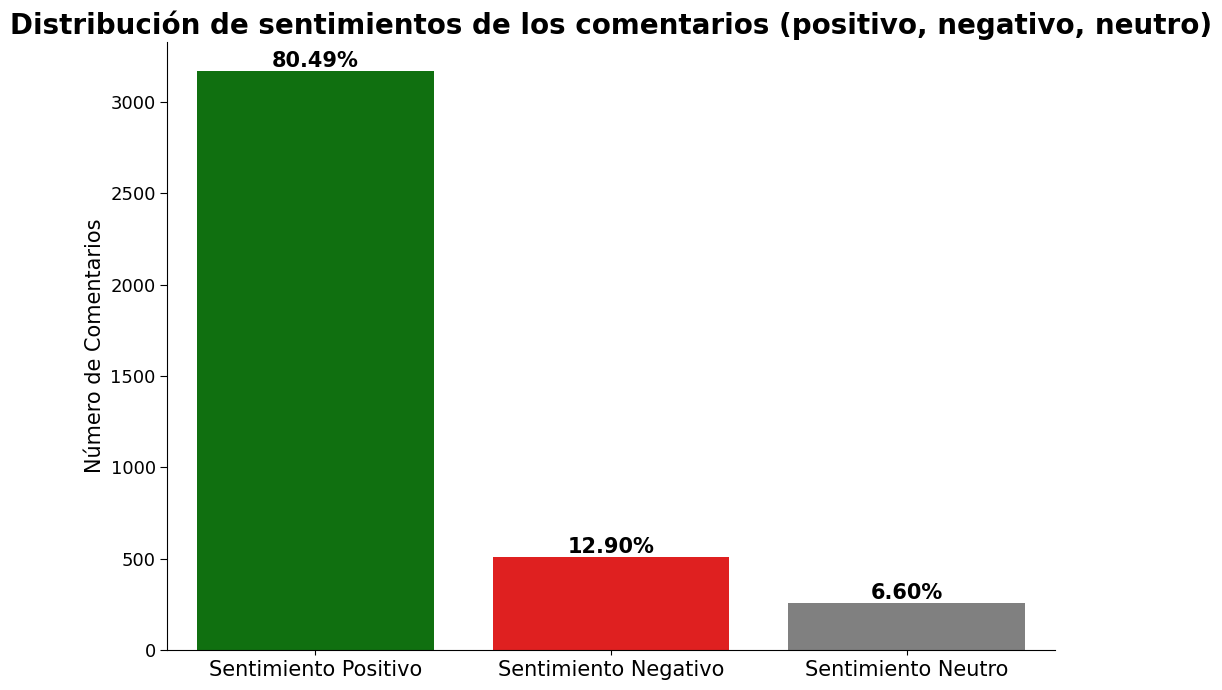

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular la frecuencia y el porcentaje de cada sentimiento
frecuencia_sentimiento = df['Sentimiento'].value_counts() # Usar la columna renombrada
porcentaje_sentimiento = df['Sentimiento'].value_counts(normalize=True) * 100 # Usar la columna renombrada

# Crear un DataFrame para facilitar la visualización
tabla_sentimiento = pd.DataFrame({
    'Frecuencia': frecuencia_sentimiento,
    'Porcentaje': porcentaje_sentimiento
}).sort_values(by='Frecuencia', ascending=False)

# Definir los colores específicos para cada sentimiento
# Asegurarse de que el orden de los colores coincida con el orden de las etiquetas en tabla_sentimiento.index
colors_map = {'POS': 'green', 'NEG': 'red', 'NEU': 'gray'}
sentimiento_colors = [colors_map[s] for s in tabla_sentimiento.index]

# Crear el gráfico de barras
plt.figure(figsize=(10, 7))
sns.barplot(x=tabla_sentimiento.index, y='Frecuencia', data=tabla_sentimiento, palette=sentimiento_colors, hue=tabla_sentimiento.index, legend=False)

# Añadir etiquetas de frecuencia y porcentaje encima de las barras
for i, row in enumerate(tabla_sentimiento.itertuples()):
    plt.text(i, row.Frecuencia, f"{row.Porcentaje:.2f}%",
             color='black', ha="center", va='bottom', fontsize=15, fontweight='bold')

plt.title('Distribución de sentimientos de los comentarios (positivo, negativo, neutro)', fontsize=20, fontweight='bold')
plt.xlabel('') # Eliminar la etiqueta del eje X
plt.ylabel('Número de Comentarios', fontsize=15) # Mostrar etiqueta del eje Y
# Cambiar las etiquetas del eje X
plt.xticks(ticks=[0, 1, 2], labels=['Sentimiento Positivo', 'Sentimiento Negativo', 'Sentimiento Neutro'], fontsize=15)
plt.yticks(fontsize=13) # Mostrar las etiquetas del eje Y y establecer tamaño de fuente
plt.tick_params(axis='y', length=5) # Mostrar los ticks del eje Y

# Quitar los bordes superior y derecho
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(True) # Asegurar que la línea izquierda del eje Y sea visible

plt.tight_layout()
plt.show()

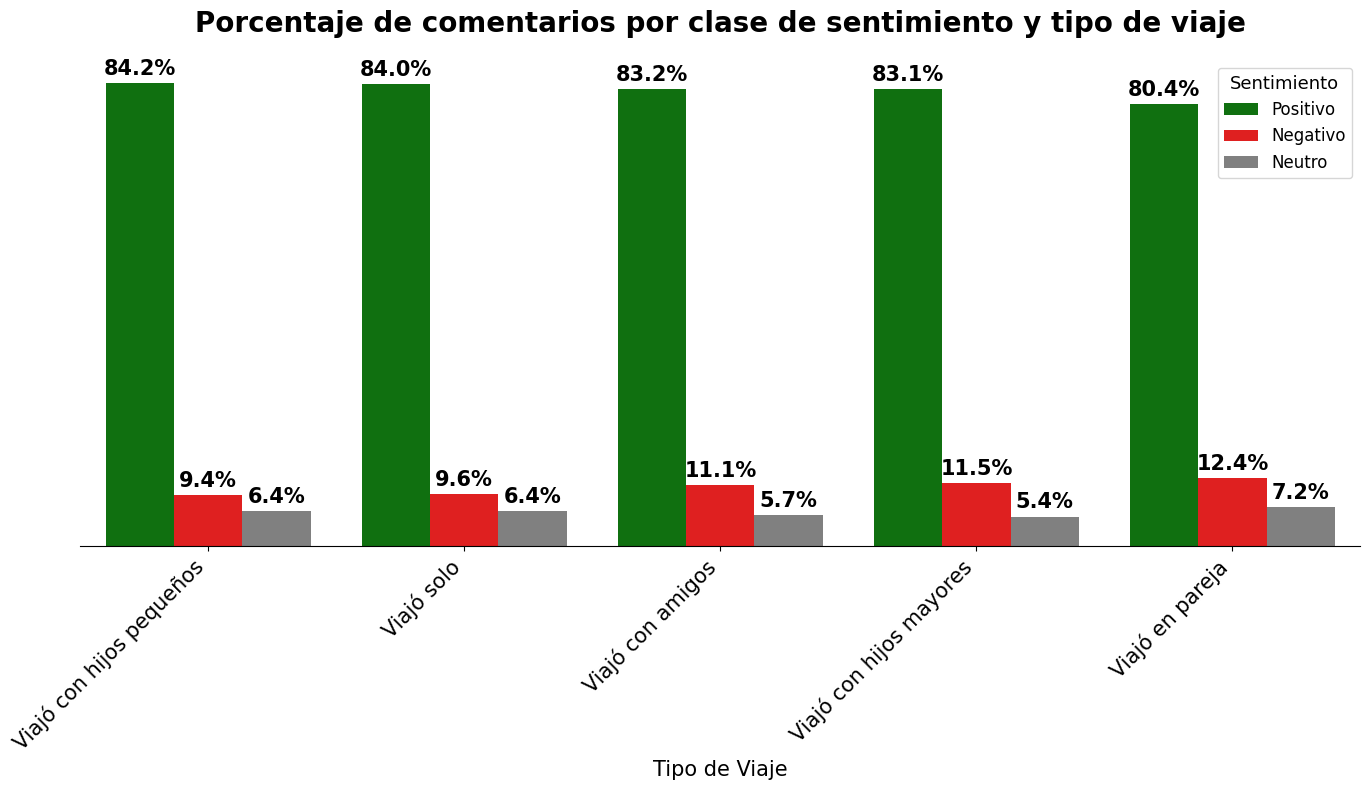

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Filter out 'No especificado' and 'Negocios' for better visualization
df_filtered_travel = df[~df['Tipo de Viaje'].isin(['No especificado', 'Negocios'])].copy()

# Combinar 'Viaje con hijos mayores' y 'Viaje con hijos pequeños' en 'Viaje con hijos'
df_filtered_travel['Tipo de Viaje_Agrupado'] = df_filtered_travel['Tipo de Viaje'].replace({
    'Viaje con hijos mayores': 'Viaje con hijos',
    'Viaje con hijos pequeños': 'Viaje con hijos'
})

# Calcular el porcentaje de cada sentimiento dentro de cada 'Tipo de Viaje_Agrupado'
sentiment_by_travel_type = df_filtered_travel.groupby('Tipo de Viaje_Agrupado')['Sentimiento'].value_counts(normalize=True).unstack(fill_value=0) * 100

# Convertir a DataFrame y derretir a formato largo para el gráfico de barras de seaborn
sentiment_melted = sentiment_by_travel_type.reset_index().melt(id_vars='Tipo de Viaje_Agrupado', var_name='Sentimiento', value_name='Porcentaje')

# Ordenar los sentimientos para colores de trazado y leyenda consistentemente
sentiment_order = ['POS', 'NEG', 'NEU']
sentiment_melted['Sentimiento'] = pd.Categorical(sentiment_melted['Sentimiento'], categories=sentiment_order, ordered=True)

# Definir colores para los sentimientos
colors_map = {'POS': 'green', 'NEG': 'red', 'NEU': 'gray'}
palette = [colors_map[s] for s in sentiment_order]

# Ordenar los tipos de viaje por porcentaje de sentimiento POS en orden descendente
sorted_travel_type_order = sentiment_by_travel_type['POS'].sort_values(ascending=False).index.tolist()

plt.figure(figsize=(14, 8))
ax = sns.barplot(
    x='Tipo de Viaje_Agrupado',
    y='Porcentaje',
    hue='Sentimiento',
    data=sentiment_melted,
    palette=palette,
    order=sorted_travel_type_order # Usar el nuevo orden
)

plt.title('Porcentaje de comentarios por clase de sentimiento y tipo de viaje', fontsize=20, fontweight='bold', pad=20)
plt.xlabel('Tipo de Viaje', fontsize=15)
plt.ylabel('') # Eliminar la etiqueta del eje Y
plt.xticks(rotation=45, ha='right', fontsize=15)
plt.yticks([]) # Eliminar los ticks del eje Y
ax.yaxis.set_visible(False) # Ocultar el eje Y

# Cambiar las etiquetas de la leyenda a español
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=['Positivo', 'Negativo', 'Neutro'], title='Sentimiento', title_fontsize='13', fontsize='12')

# Agregar la etiqueta de porcentaje en la parte superior de cada barra
for container in ax.containers:
    for patch in container.patches:
        height = patch.get_height()
        if height > 0: # Poner etiqueta sólo si la barra es visible
            ax.annotate(f'{height:.1f}%',
                        xy=(patch.get_x() + patch.get_width() / 2, height),
                        xytext=(0, 3), # Ubicación de la etiqueta
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=15, fontweight='bold')

# Quitar los bordes superior y derecho
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False) # Eliminar también la línea izquierda del eje Y

plt.tight_layout()
plt.show()

No se incluyó en el gráfico comentarios de Viaje por Negocios, porque nada más pudo recolectarse un comentario identificado así en el scraping.

El porcentaje general de comentarios positivos es menor (un poco) que el calculado por tipo de viaje. Esto sucede porque en el primero se tomaron en cuenta todos los comentarios, incluyendo aquellos que no especificaron el tipo de viaje (el 12,4% del total), a diferencia del segundo que los excluye.

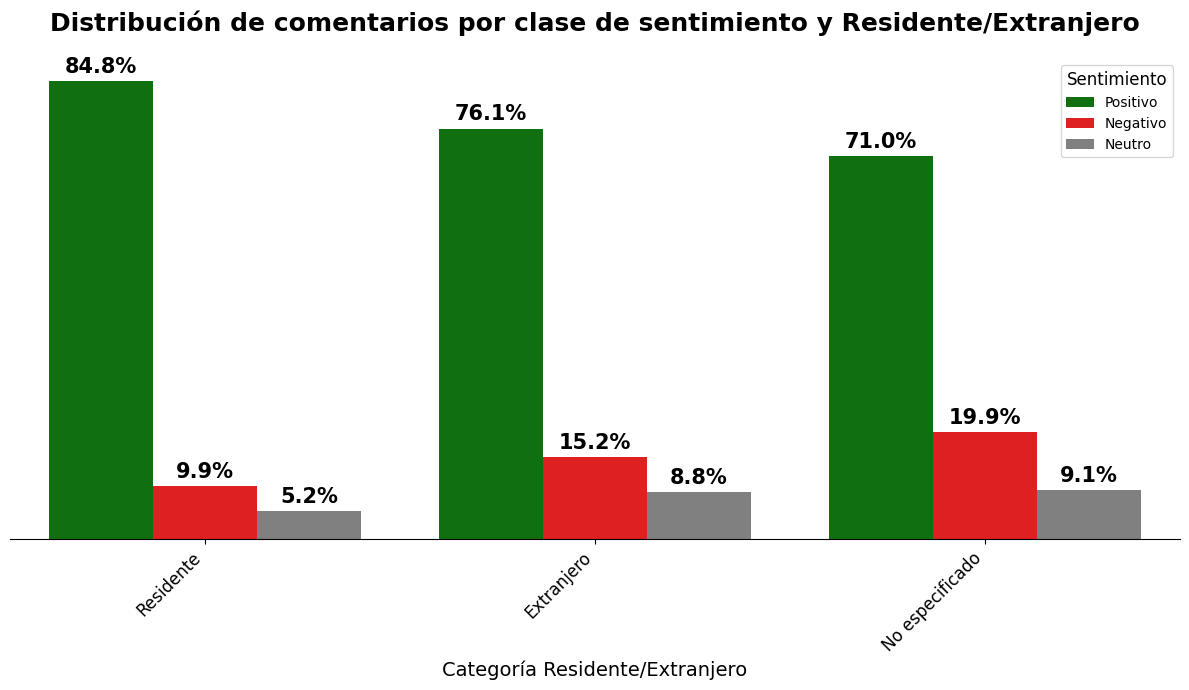

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Calcular el porcentaje de cada sentimiento dentro de las categorías de 'Residente/Extranjero'
sentiment_by_residente_extranjero_counts = df.groupby('Residente/Extranjero')['Sentimiento'].value_counts(normalize=True).unstack(fill_value=0) * 100

# Convertir el data frame y pasar a formato largo para el gráfico de barras con seaborn
sentiment_melted_re = sentiment_by_residente_extranjero_counts.reset_index().melt(id_vars='Residente/Extranjero', var_name='Sentimiento', value_name='Porcentaje')

# Ordenar los sentimientos para tener colores y leyenda de trazado consistentes
sentiment_order = ['POS', 'NEG', 'NEU']
sentiment_melted_re['Sentimiento'] = pd.Categorical(sentiment_melted_re['Sentimiento'], categories=sentiment_order, ordered=True)

# Definir colores por sentimiento
colors_map = {'POS': 'green', 'NEG': 'red', 'NEU': 'gray'}
palette = [colors_map[s] for s in sentiment_order]

plt.figure(figsize=(12, 7))
ax = sns.barplot(
    x='Residente/Extranjero',
    y='Porcentaje',
    hue='Sentimiento',
    data=sentiment_melted_re,
    palette=palette,
    order=['Residente', 'Extranjero', 'No especificado'] # Custom order for x-axis categories
)

plt.title('Distribución de comentarios por clase de sentimiento y Residente/Extranjero', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Categoría Residente/Extranjero', fontsize=14)
plt.ylabel('') # Quitar la etiqueta del eje y
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks([]) # Quitar los ticks del eje y
ax.yaxis.set_visible(False) # Ocultar el eje y

# Cambiar las etiquetas de la leyenda a español
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=['Positivo', 'Negativo', 'Neutro'], title='Sentimiento', title_fontsize='12', fontsize='10')

# Agregar la etiqueta de porcentaje en la parte superior de cada barra
for container in ax.containers:
    for patch in container.patches:
        height = patch.get_height() # This is now the percentage directly

        if height > 0: # Poner etiqueta sólo si la barra es visible
            ax.annotate(f'{height:.1f}%',
                        xy=(patch.get_x() + patch.get_width() / 2, height),
                        xytext=(0, 3), # Ubicación de la etiqueta
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=15, fontweight='bold') # Fontsize set to 15

# Quitar los bordes superior y derecho
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False) # Also hide the left spine (Y-axis line)

plt.tight_layout()
plt.show()

Mediante el análisis de sentimientos de las opiniones expresadas por los turistas, se encontró que entre los residentes españoles el 84,8% se sienten satisfechos con su visita a la ciudad de Sevilla, a diferencia de los extranjeros que manifestaron una satisfacción de un 76,1%.

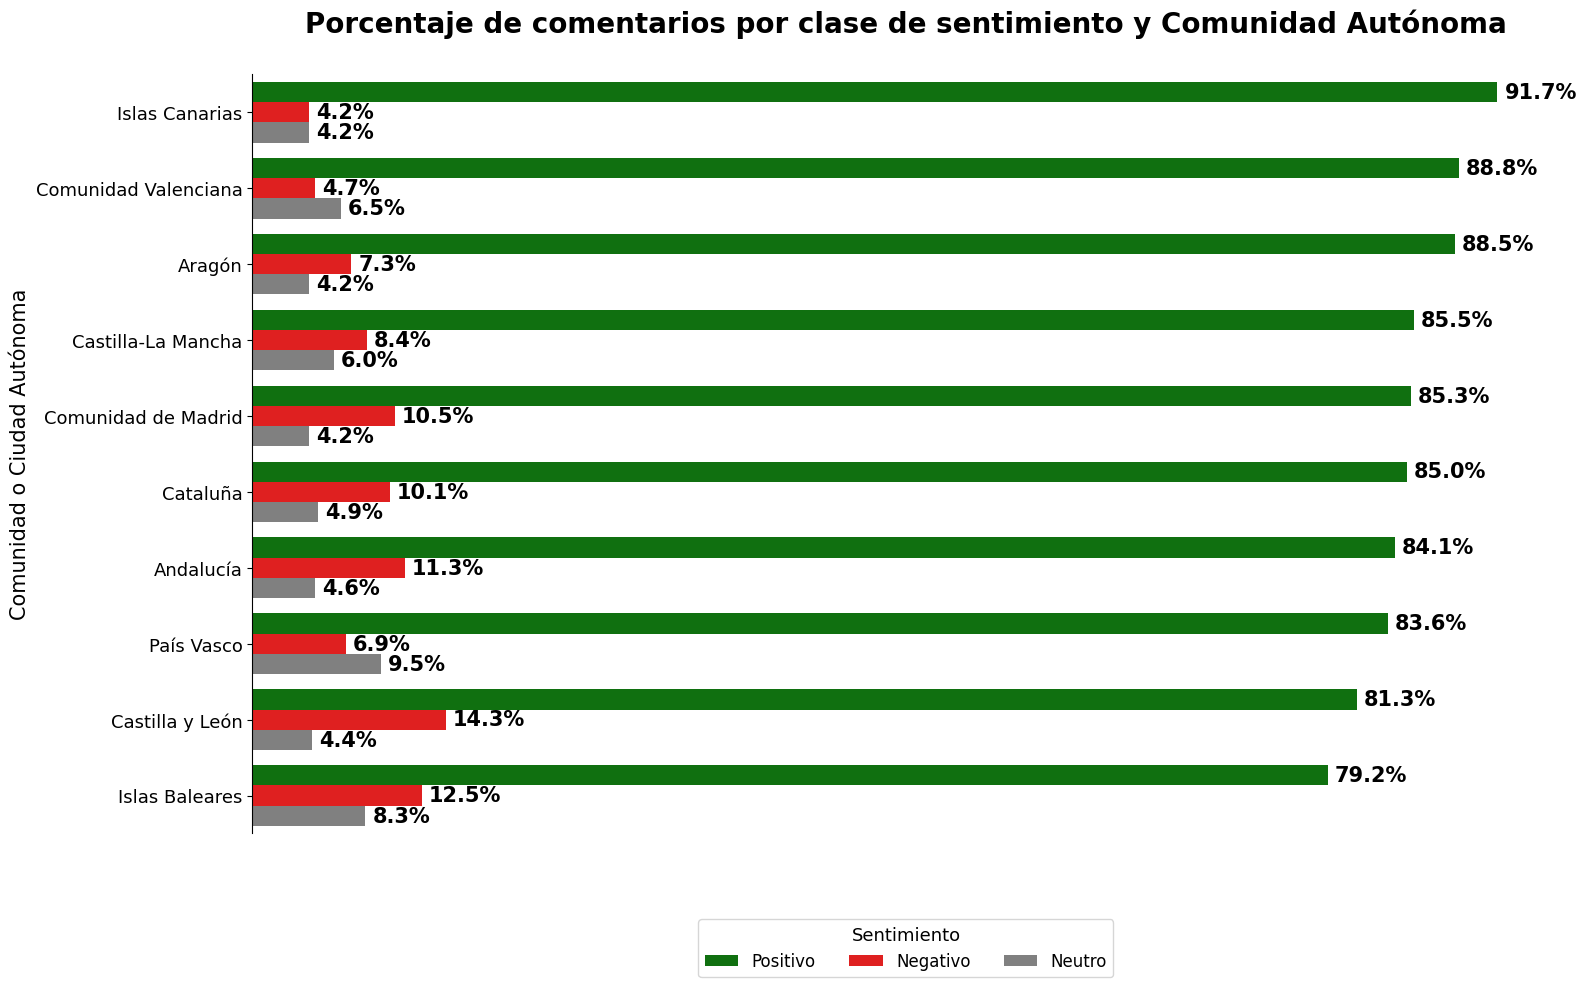

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Filtrar el DataFrame para obtener solo los comentarios de residentes y excluir 'No Aplica' de 'Comunidad o Ciudad Autónoma'
df_residentes_filtered = df[(df['Residente/Extranjero'] == 'Residente') & (df['Comunidad o Ciudad Autónoma'] != 'No Aplica')].copy()

# 2. Obtener las 10 comunidades autónomas más comentadas, excluyendo 'No especificado' para el ranking
top_10_comm_ranking = df_residentes_filtered[df_residentes_filtered['Comunidad o Ciudad Autónoma'] != 'No especificado']['Comunidad o Ciudad Autónoma'].value_counts().head(10).index.tolist()

# 3. Definir las categorías finales para el eje X, EXCLUYENDO 'No especificado'
plot_categories = top_10_comm_ranking

# 4. Filtrar el DataFrame para incluir solo estas categorías de comunidad
df_plot_comunidades = df_residentes_filtered[df_residentes_filtered['Comunidad o Ciudad Autónoma'].isin(plot_categories)].copy()

# 5. Calcular el porcentaje de cada sentimiento dentro de cada 'Comunidad o Ciudad Autónoma'
sentiment_by_community = df_plot_comunidades.groupby('Comunidad o Ciudad Autónoma')['Sentimiento'].value_counts(normalize=True).unstack(fill_value=0) * 100

# 6. Ordenar las comunidades por el porcentaje de sentimientos positivos (POS) en orden descendente
sorted_community_order = sentiment_by_community['POS'].sort_values(ascending=False).index.tolist()

# Convertir a DataFrame y derretir a formato largo para el gráfico de barras de seaborn
sentiment_melted_community = sentiment_by_community.reset_index().melt(id_vars='Comunidad o Ciudad Autónoma', var_name='Sentimiento', value_name='Porcentaje')

# Ordenar los sentimientos para colores de trazado y leyenda consistentemente
sentiment_order = ['POS', 'NEG', 'NEU']
sentiment_melted_community['Sentimiento'] = pd.Categorical(sentiment_melted_community['Sentimiento'], categories=sentiment_order, ordered=True)

# Definir colores para los sentimientos
colors_map = {'POS': 'green', 'NEG': 'red', 'NEU': 'gray'}
palette = [colors_map[s] for s in sentiment_order]

plt.figure(figsize=(16, 10)) # Aumentar un poco el tamaño para más categorías y barras horizontales
ax = sns.barplot(
    x='Porcentaje', # Eje X será el porcentaje
    y='Comunidad o Ciudad Autónoma', # Eje Y será la comunidad
    hue='Sentimiento',
    data=sentiment_melted_community,
    palette=palette,
    order=sorted_community_order # Usar el orden recién calculado
)

plt.title('Porcentaje de comentarios por clase de sentimiento y Comunidad Autónoma', fontsize=20, fontweight='bold', pad=30)
plt.xlabel('') # Eliminar la etiqueta del eje X
plt.ylabel('Comunidad o Ciudad Autónoma', fontsize=15) # Etiqueta para el eje Y (comunidad)
plt.xticks([]) # Eliminar los ticks del eje X
plt.yticks(fontsize=13) # Ticks visibles para el eje Y

# Asegurar que ambos ejes sean visibles
ax.xaxis.set_visible(False) # Ocultar completamente el eje X
ax.yaxis.set_visible(True)

# Cambiar las etiquetas de la leyenda a español y ubicarla en la parte inferior de forma horizontal
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=['Positivo', 'Negativo', 'Neutro'], title='Sentimiento', title_fontsize='13', fontsize='12', loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=3) # Legend at the bottom, horizontal

# Agregar la etiqueta de porcentaje en la parte superior/derecha de cada barra
for container in ax.containers:
    for patch in container.patches:
        width = patch.get_width() # El ancho ahora representa el porcentaje
        if width > 0: # Poner etiqueta sólo si la barra es visible
            ax.annotate(f'{width:.1f}%',
                        xy=(width, patch.get_y() + patch.get_height() / 2), # Posición al final de la barra
                        xytext=(5, 0), # Offset a la derecha de la barra
                        textcoords="offset points",
                        ha='left', va='center', fontsize=15, fontweight='bold')

# Quitar los bordes superior y derecho (y asegurar que izquierdo e inferior sean visibles)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(True) # Asegurar que el borde izquierdo (eje Y) sea visible
ax.spines['bottom'].set_visible(False) # Eliminar el borde inferior (eje X)

plt.tight_layout()
plt.show()

Si comparamos la satisfacción de los españoles según la comunidad autónoma que pertenecen, considerando solamente las diez comunidades que más comentaron, los de las Islas Canarias son los que tienen la mayor satisfacción (91,7%), seguido de los de la Comunidad Valenciana (88,8%). En décimo lugar, los turistas de Islas Baleares, la opinión positiva expresada en los comentarios engloba el 79,2%.

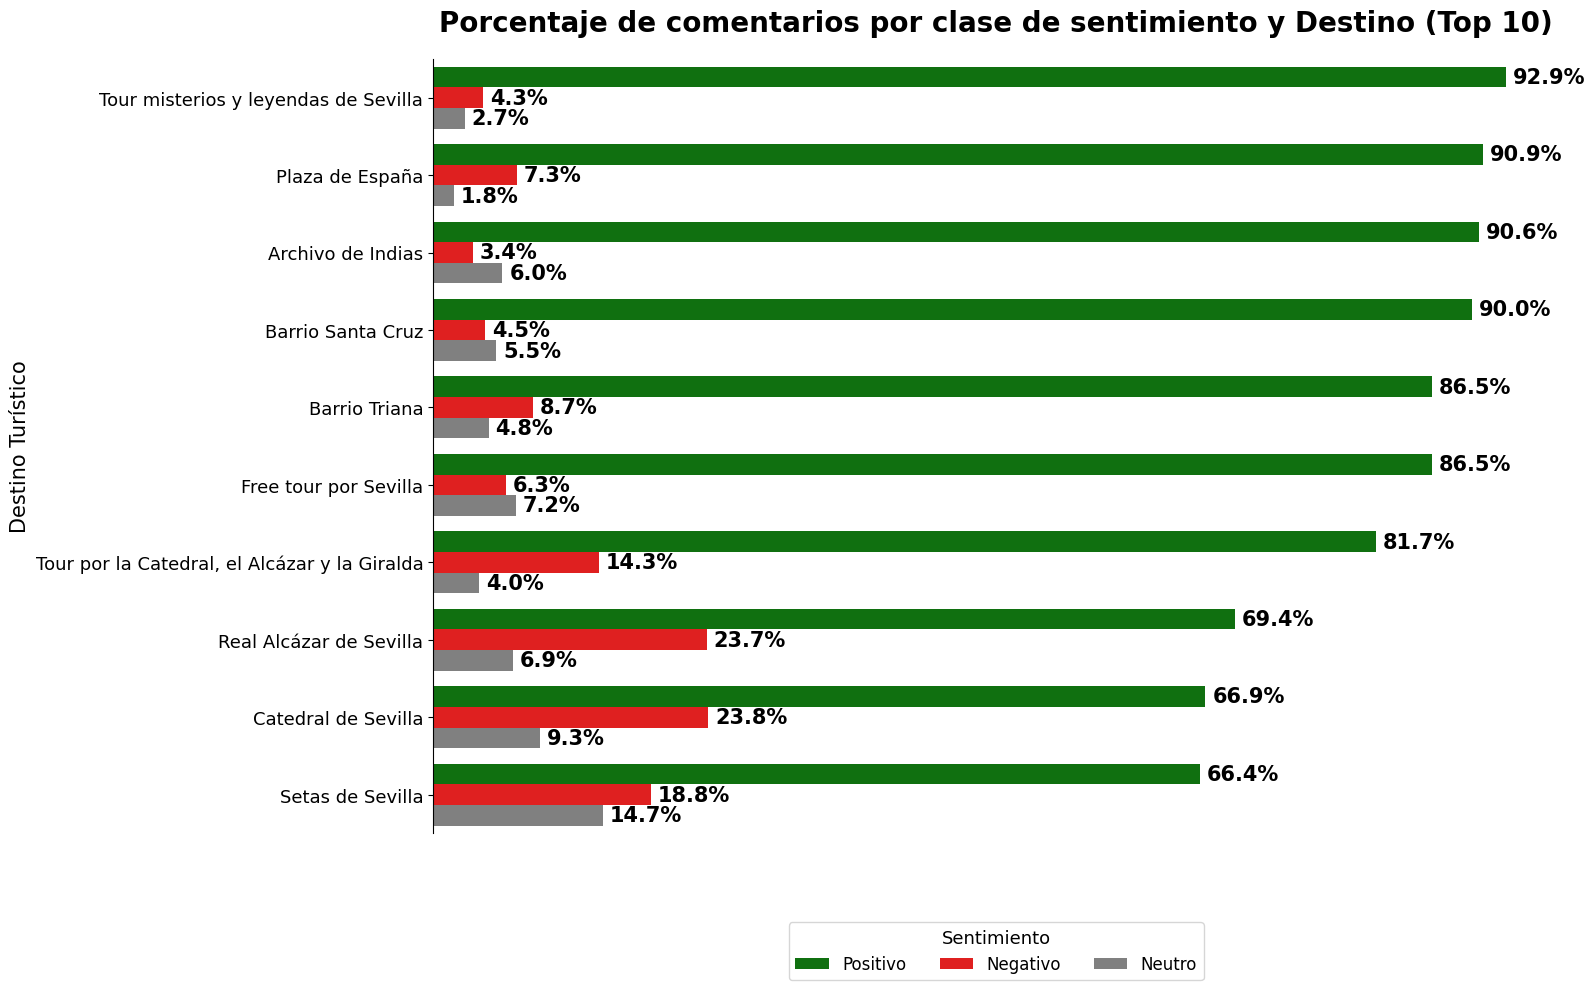

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Obtener la lista de los 10 destinos más comentados (la variable 'top_10_destinos' ya está disponible del análisis exploratorio)
top_10_destinos_list = top_10_destinos.index.tolist()

# 2. Filtrar el DataFrame principal para incluir solo los comentarios de los top 10 destinos
df_top_10_destinos = df[df['Destino'].isin(top_10_destinos_list)].copy()

# 3. Calcular el porcentaje de cada sentimiento dentro de cada 'Destino'
sentiment_by_destination = df_top_10_destinos.groupby('Destino')['Sentimiento'].value_counts(normalize=True).unstack(fill_value=0) * 100

# 4. Ordenar los destinos por el porcentaje de sentimientos positivos (POS) en orden descendente
sorted_destination_order = sentiment_by_destination['POS'].sort_values(ascending=False).index.tolist()

# 5. Convertir a DataFrame y derretir a formato largo para el gráfico de barras de seaborn
sentiment_melted_destination = sentiment_by_destination.reset_index().melt(id_vars='Destino', var_name='Sentimiento', value_name='Porcentaje')

# 6. Ordenar los sentimientos para colores de trazado y leyenda consistentemente
sentiment_order = ['POS', 'NEG', 'NEU']
sentiment_melted_destination['Sentimiento'] = pd.Categorical(sentiment_melted_destination['Sentimiento'], categories=sentiment_order, ordered=True)

# 7. Definir colores para los sentimientos
colors_map = {'POS': 'green', 'NEG': 'red', 'NEU': 'gray'}
palette = [colors_map[s] for s in sentiment_order]

plt.figure(figsize=(16, 10)) # Aumentar el tamaño para un mejor visualización de los 10 destinos
ax = sns.barplot(
    x='Porcentaje', # Eje X será el porcentaje
    y='Destino',    # Eje Y será el destino
    hue='Sentimiento',
    data=sentiment_melted_destination,
    palette=palette,
    order=sorted_destination_order # Usar el orden de destinos calculado
)

plt.title('Porcentaje de comentarios por clase de sentimiento y Destino (Top 10)', fontsize=20, fontweight='bold', pad=20)
plt.xlabel('') # Eliminar la etiqueta del eje X
plt.ylabel('Destino Turístico', fontsize=15) # Etiqueta para el eje Y (destino)
plt.xticks([]) # Eliminar los ticks del eje X
plt.yticks(fontsize=13) # Ticks visibles para el eje Y

# Asegurar que ambos ejes sean visibles
ax.xaxis.set_visible(False) # Ocultar completamente el eje X
ax.yaxis.set_visible(True)

# Cambiar las etiquetas de la leyenda a español y ubicarla en la parte inferior de forma horizontal
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=['Positivo', 'Negativo', 'Neutro'], title='Sentimiento', title_fontsize='13', fontsize='12', loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=3)

# Agregar la etiqueta de porcentaje en la parte superior/derecha de cada barra
for container in ax.containers:
    for patch in container.patches:
        width = patch.get_width() # El ancho ahora representa el porcentaje
        if width > 0: # Poner etiqueta sólo si la barra es visible
            ax.annotate(f'{width:.1f}%',
                        xy=(width, patch.get_y() + patch.get_height() / 2), # Posición al final de la barra
                        xytext=(5, 0), # Offset a la derecha de la barra
                        textcoords="offset points",
                        ha='left', va='center', fontsize=15, fontweight='bold')

# Quitar los bordes superior y derecho (y asegurar que izquierdo e inferior sean visibles)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(True) # Asegurar que el borde izquierdo (eje Y) sea visible
ax.spines['bottom'].set_visible(False) # Eliminar el borde inferior (eje X)

plt.tight_layout()
plt.show()

Viendo en más detalle la satisfacción de los turistas según los 10 lugares más visitados de la ciudad de Sevilla (incluye tours, museos, parques, etc.), el tour sobre misterios y leyendas de Sevilla fue el mejor valorado por las opiniones de los turistas alcanzando un 92,9% de aprobación positiva, seguido de la Plaza España cuyos visitantes tienen una satisfacción de 90,9%. En los últimos tres lugares están: el Real Alcázar de Sevilla (69,4%), la Catedral de Sevilla (66,9%) y las Setas de Sevilla (66,4%). Estos tres lugares turísticas representaron el 24,31% de los comentarios recolectados, por lo que merecen especial atención, en vista de que producen una baja satisfacción de los turistas y debería hacerse un plan de acción de mejora.

In [ ]:
# Tabla de frecuencia de comentarios positivos, negativos y neutros segun el destino

import pandas as pd

# Calcular la frecuencia de cada sentimiento por destino
sentiment_counts = df.groupby(['Destino', 'Sentimiento']).size().unstack(fill_value=0)

# Calcular el total de comentarios por destino
total_comments_per_destination = sentiment_counts.sum(axis=1)

# Calcular el porcentaje de cada sentimiento por destino
sentiment_percentages = sentiment_counts.divide(total_comments_per_destination, axis=0) * 100

# Renombrar columnas para claridad
sentiment_counts = sentiment_counts.rename(columns={'POS': 'Frecuencia POS', 'NEG': 'Frecuencia NEG', 'NEU': 'Frecuencia NEU'})
sentiment_percentages = sentiment_percentages.rename(columns={'POS': 'Porcentaje POS', 'NEG': 'Porcentaje NEG', 'NEU': 'Porcentaje NEU'})

# Unir las tablas de frecuencia y porcentaje
result_table = pd.concat([sentiment_counts, sentiment_percentages], axis=1)

# Reordenar las columnas para mejor visualización (Frecuencia POS, Porcentaje POS, Frecuencia NEG, Porcentaje NEG, Frecuencia NEU, Porcentaje NEU)
result_table = result_table[['Frecuencia POS', 'Porcentaje POS', 'Frecuencia NEG', 'Porcentaje NEG', 'Frecuencia NEU', 'Porcentaje NEU']]

# Ordenar la tabla por 'Porcentaje POS' de forma descendente
result_table_sorted = result_table.sort_values(by='Porcentaje POS', ascending=False)

# Mostrar la tabla ordenada
display(result_table_sorted.round(2))

Sentimiento,Frecuencia POS,Porcentaje POS,Frecuencia NEG,Porcentaje NEG,Frecuencia NEU,Porcentaje NEU
Destino,,,,,,
Centro Histórico,16,100.00,0,0.00,0,0.00
Espectáculo de flamenco Baraka Sala,1,100.00,0,0.00,0,0.00
Paseo por el río Guadalquivir en kayak,9,100.00,0,0.00,0,0.00
Tour en segway por Sevilla,1,100.00,0,0.00,0,0.00
Tour en bicicleta por Sevilla,8,100.00,0,0.00,0,0.00
Palacio de la Condesa de Lebrija,18,94.74,0,0.00,1,5.26
Museo del Baile Flamenco,30,93.75,2,6.25,0,0.00
Tour misterios y leyendas de Sevilla,407,92.92,19,4.34,12,2.74
Espectáculo de flamenco Sala Almoraima,12,92.31,0,0.00,1,7.69


# **Análisis de contenido**

### **Nube de palabras**

Por medio de una nube de palabras se visualizan las palabras más mencionadas en los comentarios, los cuales se presentan de mayor tamaño en el gráfico.

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


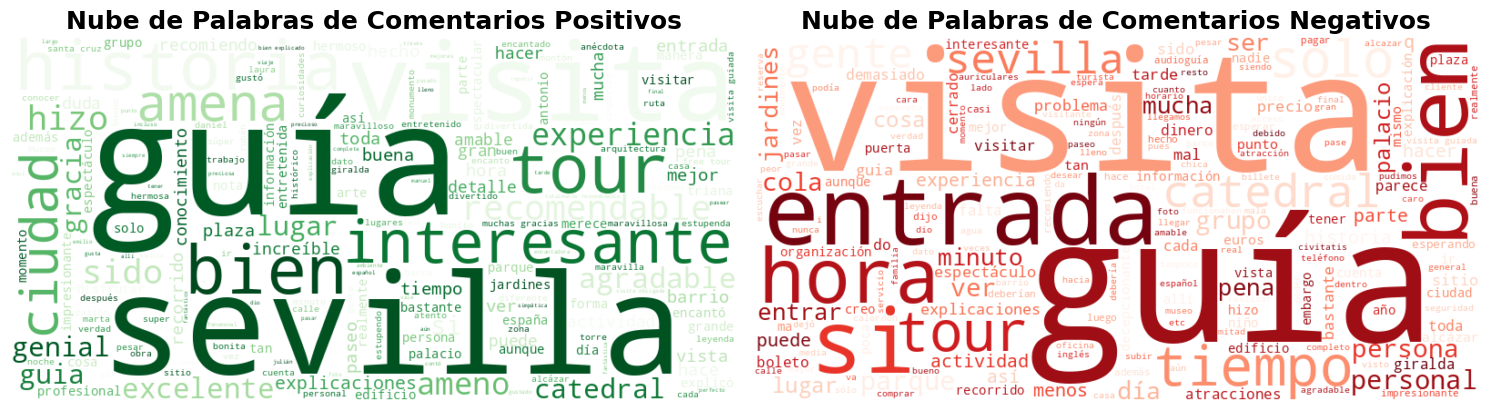

In [ ]:
!pip install wordcloud nltk

from wordcloud import WordCloud
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
spanish_stopwords = set(stopwords.words('spanish'))

# Filtrar comentarios positivos
positive_comments = ' '.join(df[df['Sentimiento'] == 'POS']['Comentario_limpio'].dropna().tolist())

# Filtrar comentarios negativos
negative_comments = ' '.join(df[df['Sentimiento'] == 'NEG']['Comentario_limpio'].dropna().tolist())

# Generar Word Cloud para comentarios positivos, excluyendo stopwords
wordcloud_positive = WordCloud(width=800, height=400, background_color='white', colormap='Greens', stopwords=spanish_stopwords).generate(positive_comments)

# Generar Word Cloud para comentarios negativos, excluyendo stopwords
wordcloud_negative = WordCloud(width=800, height=400, background_color='white', colormap='Reds', stopwords=spanish_stopwords).generate(negative_comments)

# Visualizar las nubes de palabras
plt.figure(figsize=(15, 8))

plt.subplot(1, 2, 1)
plt.imshow(wordcloud_positive, interpolation='bilinear')
plt.title('Nube de Palabras de Comentarios Positivos', fontsize=18, fontweight='bold')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(wordcloud_negative, interpolation='bilinear')
plt.title('Nube de Palabras de Comentarios Negativos', fontsize=18, fontweight='bold')
plt.axis('off')

plt.tight_layout()
plt.show()

### **Los 10 comentarios más positivos**

In [ ]:
# Filtrar los comentarios que fueron clasificados como POS (Positivos)
positive_comments_df = df[df['Sentimiento'] == 'POS']

# Ordenar por 'Puntuacion_Sentimiento' de forma descendente y seleccionar los 5 primeros
top_10_positive_comments = positive_comments_df.sort_values(by='Puntuacion_Sentimiento', ascending=False).head(10)

# Mostrar los resultados en una tabla
print("--- Los 10 comentarios más positivos ---")
display(top_10_positive_comments[['Comentario', 'Sentimiento', 'Puntuacion_Sentimiento']])

--- Los 10 comentarios más positivos ---


,Comentario,Sentimiento,Puntuacion_Sentimiento
1228,Muy buena la visita y Julián es un guía espect...,POS,0.985523
2670,Nos encantó el tour. Antonio es un guía muy ag...,POS,0.985463
2267,"Visita estupenda, y Marcos un guía fantástico,...",POS,0.985317
122,Muy bonito un guía excelente muy cordial y hac...,POS,0.985042
180,Me encantó. Es una visita muy agradable con un...,POS,0.984981
2261,Estupenda. Realmente merece la pena visitar es...,POS,0.984779
2899,"Una actividad muy chula, el paseo muy agradabl...",POS,0.984555
724,"Víctor fue un muy buen guía, me dio gusto el tour",POS,0.984374
2214,"Álvaro es un chico encantador, amable. Un gran...",POS,0.984364
1444,Muy buen. Muy a gusto y con una guía fantástica.,POS,0.984280


### **Los 10 comentarios más negativos**

In [ ]:
# Filtrar los comentarios que fueron clasificados como NEG (Negativos)
negative_comments_df = df[df['Sentimiento'] == 'NEG']

# Ordenar por 'Puntuacion_Sentimiento' de forma descendente y seleccionar los 5 primeros
top_10_negative_comments = negative_comments_df.sort_values(by='Puntuacion_Sentimiento', ascending=False).head(10)

# Mostrar los resultados en una tabla
print("--- Los 10 comentarios más negativos ---")
display(top_10_negative_comments[['Comentario', 'Sentimiento', 'Puntuacion_Sentimiento']])

--- Los 10 comentarios más negativos ---


,Comentario,Sentimiento,Puntuacion_Sentimiento
3139,Me he gastado un dineral en el pase de tempora...,NEG,0.987473
3115,La sensación es de una acumulación de obras de...,NEG,0.985873
3450,Lamentable los tíos del mostrador unos chulopl...,NEG,0.984595
3579,Todos los años hacemos una visita y este año h...,NEG,0.984513
218,"Las explicación de la Guía no fue nada buens,s...",NEG,0.984170
3322,"Sacarse el pase de leyenda, no merece para nad...",NEG,0.983940
3460,"El palacio en sí es extraordinario, pero la ex...",NEG,0.983858
3872,"Esta es, sin duda, una de las mayores decepcio...",NEG,0.983449
954,El free tour se hizo un poco pesado. Un poco l...,NEG,0.983166
3162,La visita a Isla Mágica ha sido una decepción ...,NEG,0.983012


### **Los 20 bigramas más frecuentes en comentarios positivos**

In [ ]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.collocations import BigramCollocationFinder, BigramAssocMeasures

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True) # Add this line to download the missing resource
spanish_stopwords = set(stopwords.words('spanish'))

# Filtrar comentarios positivos
positive_comments_text = ' '.join(df[df['Sentimiento'] == 'POS']['Comentario_limpio'].dropna().tolist())

# Tokenizar y filtrar stopwords
words = word_tokenize(positive_comments_text, language='spanish')
filtered_words = [word for word in words if word.isalpha() and word not in spanish_stopwords]

# Encontrar bigramas
finder = BigramCollocationFinder.from_words(filtered_words)

# Obtener los 20 bigramas más frecuentes
bigram_measures = BigramAssocMeasures()
top_20_bigrams = finder.nbest(bigram_measures.raw_freq, 20) # raw_freq para frecuencia absoluta

# Calcular frecuencia y porcentaje
bigram_counts = {}
for bigram in top_20_bigrams:
    count = finder.ngram_fd[bigram]
    bigram_counts[bigram] = count

total_bigrams = sum(finder.ngram_fd.values())

data = []
for bigram, count in bigram_counts.items():
    percentage = (count / total_bigrams) * 100
    data.append({'Bigrama': ' '.join(bigram), 'Frecuencia': count, 'Porcentaje': percentage})

# Crear DataFrame y mostrar
df_bigrams = pd.DataFrame(data)
display(df_bigrams.sort_values(by='Frecuencia', ascending=False).round(2))

,Bigrama,Frecuencia,Porcentaje
0,muchas gracias,87,0.17
1,merece pena,79,0.16
2,visita guiada,69,0.14
3,free tour,63,0.12
4,santa cruz,60,0.12
5,plaza españa,59,0.12
6,vale pena,58,0.11
7,totalmente recomendable,55,0.11
8,barrio santa,53,0.10
9,visita amena,53,0.10


### **Los 20 bigramas más frecuentes en comentarios negativos**

In [ ]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.collocations import BigramCollocationFinder, BigramAssocMeasures

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True) # Add this line to download the missing resource
spanish_stopwords = set(stopwords.words('spanish'))

# Filtrar comentarios positivos
negative_comments_text = ' '.join(df[df['Sentimiento'] == 'NEG']['Comentario_limpio'].dropna().tolist())

# Tokenizar y filtrar stopwords
words = word_tokenize(negative_comments_text, language='spanish')
filtered_words = [word for word in words if word.isalpha() and word not in spanish_stopwords]

# Encontrar bigramas
finder = BigramCollocationFinder.from_words(filtered_words)

# Obtener los 20 bigramas más frecuentes
bigram_measures = BigramAssocMeasures()
top_20_bigrams = finder.nbest(bigram_measures.raw_freq, 20) # raw_freq para frecuencia absoluta

# Calcular frecuencia y porcentaje
bigram_counts = {}
for bigram in top_20_bigrams:
    count = finder.ngram_fd[bigram]
    bigram_counts[bigram] = count

total_bigrams = sum(finder.ngram_fd.values())

data = []
for bigram, count in bigram_counts.items():
    percentage = (count / total_bigrams) * 100
    data.append({'Bigrama': ' '.join(bigram), 'Frecuencia': count, 'Porcentaje': percentage})

# Crear DataFrame y mostrar
df_bigrams = pd.DataFrame(data)
display(df_bigrams.sort_values(by='Frecuencia', ascending=False).round(2))

,Bigrama,Frecuencia,Porcentaje
0,visita guiada,20,0.13
1,merece pena,12,0.08
2,isla mágica,11,0.07
3,plaza españa,10,0.07
4,guía bien,9,0.06
5,hora media,9,0.06
6,jardines cerrados,9,0.06
7,todas partes,9,0.06
8,free tour,8,0.05
9,primera vez,8,0.05


In [ ]:
df_negative_comments = df[df['Sentimiento'] == 'NEG']
display(df_negative_comments.head())

,Destino,web_scraper_order,Fuente,URL,Fecha de Publicación,Nombre del Usuario,Título del Comentario,Fecha de Viaje,Tipo de Viaje,Comentario,Lugar de Procedencia,País,Residente/Extranjero,Comunidad o Ciudad Autónoma,Comentario_limpio,Sentimiento,Puntuacion_Sentimiento,Probabilidad Sentimiento NEG,Probabilidad Sentimiento NEU,Probabilidad Sentimiento POS
2,Isla Mágica,1775652240-9,TripAdvisor,https://www.tripadvisor.es/Attraction_Review-g...,2025-08-08,Brian D,No especificado,NaT,No especificado,Experiencia pirata no sirve solo es publicidad...,"Las Palmas de Gran Canaria, España",España,Residente,Islas Canarias,experiencia pirata no sirve solo es publicidad...,NEG,0.954234,0.954234,0.040280,0.005486
7,Catedral de Sevilla,1776037931-10,Civitatis,https://www.civitatis.com/es/sevilla/visita-gu...,2025-06-21,Adrián,No especificado,No especificado,Viajó con amigos,Nada más reservarlo a través de la web de civi...,España,España,Residente,No especificado,nada más reservarlo a través de la web de civi...,NEG,0.947337,0.947337,0.049918,0.002745
17,Setas de Sevilla,1775818716-3,Civitatis,https://www.civitatis.com/es/sevilla/entrada-s...,2025-08-30,Adriana Orge,No especificado,No especificado,Viajó en pareja,Compré entradas desde Argentina p senior y cua...,"Funes, Argentina",Argentina,Extranjero,No aplica,compré entradas desde argentina p senior y cua...,NEG,0.500343,0.500343,0.486050,0.013606
20,Barrio Santa Cruz,1776039058-7,Civitatis,https://www.civitatis.com/es/sevilla/free-tour...,2025-09-29,Agustín,No especificado,No especificado,Viajó solo,El muchacho llegó sobre la hora (pidió disculp...,"Valencia, España",España,Residente,Comunidad Valenciana,el muchacho llegó sobre la hora pidió disculpa...,NEG,0.899085,0.899085,0.095827,0.005088
21,Catedral de Sevilla,1775612744-8,TripAdvisor,https://www.tripadvisor.es/Attraction_Review-g...,2025-08-10,Beatrice N,terrible experiencia!,NaT,No especificado,¡Trae algo para taparte! Aunque haga 57 grados...,No especificado,Francia,No especificado,No aplica,trae algo para taparte aunque haga 57 grados n...,NEG,0.809334,0.809334,0.171696,0.018970


In [ ]:
# Dimensiones del subconjunto de datos que contiene solamente comentarios negativos
print(df_negative_comments.shape)

(508, 20)


In [ ]:
# Guardar el DataFrame de comentarios negativos en un archivo CSV
df_negative_comments.to_csv('/content/drive/MyDrive/comentarios_negativos.csv', index=False)
print("DataFrame 'df_negative_comments' guardado exitosamente en 'comentarios_negativos.csv' en Google Drive.")

DataFrame 'df_negative_comments' guardado exitosamente en 'comentarios_negativos.csv' en Google Drive.


In [ ]:
import json

notebook_path = "/content/drive/MyDrive/Seville_Tourist_Satisfaction_Analysis.ipynb"

with open(notebook_path, "r", encoding="utf-8") as f:
    nb = json.load(f)

if "widgets" in nb.get("metadata", {}):
    del nb["metadata"]["widgets"]

clean_path = "/content/drive/MyDrive/Seville_Tourist_Satisfaction_Analysis_clean.ipynb"

with open(clean_path, "w", encoding="utf-8") as f:
    json.dump(nb, f, ensure_ascii=False, indent=1)

print("Notebook limpio guardado en:", clean_path)

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Seville_Tourist_Satisfaction_Analysis.ipynb'